### Import

In [1]:
import os
import gc
import time
import pickle 
import itertools
import numpy as np
import pandas as pd
import seaborn as sns
from tqdm.auto import tqdm
import matplotlib.ticker as ticker
from matplotlib import pyplot as plt 

from typing import Dict
from typing import Callable
from plot_metric.functions import BinaryClassification

import pyarrow as pa
import pyarrow.parquet as pq

import statsmodels.api as sm
from scipy.stats import spearmanr

from pynvml import *
import GPUtil
from threading import Thread

from sklearn.metrics import auc
from sklearn.metrics import f1_score 
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import matthews_corrcoef
from sklearn.metrics import average_precision_score
from sklearn.metrics import precision_recall_curve
from sklearn.calibration import calibration_curve

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

from aequitas.bias import Bias
from aequitas.group import Group
from aequitas.plotting import Plot
from aequitas.fairness import Fairness

import torch
import torch.nn as nn
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
from torch.utils.data.sampler import WeightedRandomSampler

from torch.nn.utils.rnn import pad_packed_sequence
from torch.nn.utils.rnn import pack_padded_sequence

from torch.optim import AdamW
from transformers import get_scheduler
from transformers import get_linear_schedule_with_warmup

from captum.attr import IntegratedGradients

pd.set_option('display.max_columns', 500)

### General parameters

In [2]:
path_data  = "./Data/"
best_model = "./checkpoints/"

### Reading Data

In [3]:
df_ehr = pd.read_csv(path_data + 'all_24h_data.csv', low_memory=False, index_col=False)
df_ehr = df_ehr[df_ehr.datetime != 0.0]
df_ehr.head(2)

In [4]:
print(df_ehr.patientid.nunique())
print(df_ehr.shape)

33811
(706601, 797)


### Read Demographics

In [6]:
df_demog = pd.read_csv(path_data + 'demographic_all.csv', low_memory=False, index_col=False)
df_demog = df_demog[['patientid', 'sex', 'height', 'weight', 'discharge_status', 'Los']]
df_demog['gender'] = 1
df_demog.loc[df_demog.sex == 'F', 'gender'] = 2
df_demog['icuLos_h'] = df_demog['Los'] * 24
df_demog = df_demog[~df_demog['discharge_status'].isnull()]
df_demog['icu_expire_flag'] = 0
df_demog.loc[df_demog.discharge_status == 'dead', 'icu_expire_flag'] = 1
df_demog = df_demog[['patientid', 'gender', 'height', 'weight', 'icuLos_h', 'icu_expire_flag']]
df_demog.head(3)

In [7]:
print(df_demog.patientid.nunique())
print(df_demog.shape)

33577
(33577, 6)


### Combine Data & Demographics

In [8]:
df_ehr = df_ehr.merge(df_demog, on='patientid', how='right')
df_ehr.head(2)

In [9]:
print(df_ehr.patientid.nunique())
print(df_ehr.shape)

33577
(701344, 802)


### Take first hours of ICU of patients with more than 24 hour LoS

In [10]:
observation_window = 24
observation_length = 24

In [11]:
def short_long_icustays(df, observation_window):
    
    short_stays = df[df.icuLos_h < observation_window].copy()
    short_stays = short_stays.groupby('patientid').head(observation_length).reset_index(drop=True)

    long_stays = df[df.icuLos_h >= observation_window].copy()
    long_stays = long_stays.groupby('patientid').head(observation_length).reset_index(drop=True)
    
    return long_stays, short_stays

In [12]:
df_long, df_short = short_long_icustays(df_ehr, observation_window)

In [13]:
print(df_long.patientid.nunique())
print(df_long.shape)

print(df_short.patientid.nunique())
print(df_short.shape)

16642
(399055, 802)
16935
(302289, 802)


In [14]:
del df_ehr
gc.collect()

20

### Spliting Train - Validation - Test

In [15]:
split_label = 'icu_expire_flag'
label = 'icu_expire_flag'

In [16]:
def split_train_test(long_stays, short_stays, label):
    
    indexing = long_stays[['patientid', label]].groupby('patientid').head(1)
    train_id, test_id  = train_test_split(indexing, stratify= indexing[label], test_size= 0.20, random_state= 42)
    train_id, valid_id = train_test_split(train_id, stratify= train_id[label], test_size= 0.15, random_state= 42)
    
    index_train = train_id.patientid.unique()
    index_valid = valid_id.patientid.unique()
    index_test  = test_id.patientid.unique()

    train_df = long_stays[long_stays['patientid'].isin(index_train)].copy()
    valid_df = long_stays[long_stays['patientid'].isin(index_valid)].copy()
    test_df  = long_stays[long_stays['patientid'].isin(index_test)].copy()

    concat_df = [train_df, short_stays]
    train_df  = pd.concat(concat_df)
    
    train_df[[label]] = train_df[[label]].astype(int)
    valid_df[[label]] = valid_df[[label]].astype(int)
    test_df[[label]]  = test_df[[label]].astype(int)
    
    train_df.sort_values(by=['patientid', 'datetime'], inplace=True)
    valid_df.sort_values(by=['patientid', 'datetime'], inplace=True)
    test_df.sort_values( by=['patientid', 'datetime'], inplace=True)
    
    train_df = train_df.reset_index(drop=True)
    valid_df = valid_df.reset_index(drop=True)
    test_df  = test_df.reset_index(drop=True)
    
    return train_df, valid_df, test_df

In [17]:
train_df, valid_df, test_df = split_train_test(df_long, df_short, split_label)

### Variables Selection

In [18]:
continuse_col = ['Pulmonary artery mean pressure', 
                 'Pulmonary artery wedge pressure',  'Pulmonary artery systolic pressure', 
                 'Pulmonary artery diastolic pressure', 'Cardiac Output', 'SvO2(m)','Central venous pressure', 
                 'ETCO2',  'ICP', 'TOF', 'FIO2', 'Peep', 'TV', 'Peak Inspiratory Pressure',
                 'Plateau Pressure', 'Mean Inspiratory Airway Pressure', 'Respiratory Rate (Set)', 
                 'Central venous pressure', 'ICP','Liquor/h (output from drain)', 
                 'Base Excess', 'Carboxy Hemoglobin', 'Hemoglobin', 'Bicarbonate', 'Lactate', 'Methemoglobin', 
                 'pH', 'pCO2', 'PO2', 'Oxygen Saturation_SO2', 'CV Oxygenation Saturation', 'Troponin-T',
                 'Creatine kinase', 'Creatine kinase-MB', 'BNP', 'Potassium', 'Sodium', 'Chloride', 
                 'Calcium Ionized', 'Calcium', 'Phosphate', 'Magnesium', 'Urea', 'Creatinine', 'urinary creatinin', 
                 'urinary sodium', 'urinary urea', 'AST', 'ALT', 'Bilirubine, Total', 'Bilirubin, Direct', 
                 'Alkaline Phosphatase', 'gamma-GT', 'PTT', 'Fibrinogen', 'FII', 'Factor V (Coagulation)', 
                 'Factor VII (Coagulation)', 'Factor X (Coagulation)', 'INR', 'Albumin', 'Glucose',
                 'Ammonia', 'C-reactive protein', 'Procalcitonin', 'Lymphocytes', 'Neutrophils', 
                 'Segmented Neutrophils', 'Band Neutrophils', 'BSR', 'White Blood Cell count', 'Platelet Count', 
                 'MCH', 'MCHC', 'MCV', 'Ferritin', 'TSH', 'Amylase', 'Lipase', 'Cortisol', 'pH Liquor', 
                 'Lactate Liquor', 'Glucose Liquor', 'pH Drain', 'Amylase Drain', 'BUN', 'Out Urine/h', 
                 'Fluid Balance IN', 'Fluid Balance OUT', 'Incrys (saline solution)','Incolloid']

categorical_col = ['Ventilator mode', 'Heart Rhythm', 'supplemental oxygen', 'GCS Verbal', 'GCS Motor', 
                   'GCS Eye', 'RASS', 'Ventilator Airway Code', 'Haemofiltration', 'Total GCS']

binary_col = ['Non-opioide', 'Opiate', 'Administriation of antibiotics', 'Propofol', 'Heparin', 'Mg', 
              'Insulin Rapid', 'Kalium', 'Thrombozytenhemmer', 'norepinephrine', 'Loop diuretics',
              'Benzodiacepine', 'VitB Substitution', 'B-Blocker', 'vasodilatators', 'ACE Inhibitors', 
              'packed red blood cells', 'Muskelrelaxans', 'Andere', 'Steroids', 'Enteral Feeding',
              'Phosphat', 'non-steroids', 'dobutamine', 'Anti delirant medi', 'Antiepileptica']

risk_scores = ['PaO2/FiO2', 'SIRS', 'Shock_Index', 'SOFA', 'SAPSII', 'OASIS']

static_col = ['age', 'gender', 'weight', 'height']

### Remove pharma variables with more than 90% missing values 

In [19]:
pharma_90missing = ['Anti Fibrinolyticum', 'Thiazide', 'Trace elements', 'Chemotherapie', 'NSAR',
                    'Adenosin', 'Antihistaminka', 'Ketalar', 'Insulin Lantus', 'administration of antiviral',
                    'Immunoglobulin', 'Thyreostatikum', 'Parkinson Medikaiton', 'Glucose Administration',
                    'Na', 'NMH', 'Naloxon', 'epinephrine', 'Aldosteron Antagonist', 'Ca', 'Protamin', 
                    'Nimodipin', 'Peripherial Anesthesia', 'Acetazolamide', 'Marcoumar', 'vasopressors', 
                    'Digoxin', 'Pankreas Enzyme', 'GCSF', 'Thyroxin', 'Mineralokortikoid', 'Amiodaron',
                    'Psychopharma', 'Anexate', 'Ca Antagonists', 'theophyllin', 'Na-Bicarbonate',
                    'Sartane', 'Beh. Pulm. Hypertonie', 'Lysetherapie', 'Parenteral Feeding', 'platelets',
                    'Antihelmenticum', 'K-sparend', 'Others in Case of HIT', 'milrinone', 'Immunsuppression',
                    'Thyrotardin', 'FFP', 'levosimendan', 'Atropin', 'Barbiturate', 'vasopressin', 
                    'Administation of antimycotic', 'desmopressin', 'Terlipressin', 'Alpha 2 Agonisten',
                    'steroids', 'coagulation factors', 'Weight']

In [20]:
train_df = train_df.drop(pharma_90missing, axis=1)
valid_df = valid_df.drop(pharma_90missing, axis=1)
test_df  = test_df.drop( pharma_90missing, axis=1)

### Imputation

In [21]:
def Imputation(train_df, valid_df, test_df, continuse_col, categorical_col, binary_col, risk_scores):
    
    train_df['weight'] = train_df.groupby(['patientid'])['weight'].transform('mean') 
    valid_df['weight'] = valid_df.groupby(['patientid'])['weight'].transform('mean') 
    test_df[ 'weight'] = test_df.groupby( ['patientid'])['weight'].transform('mean') 
    train_df['height'] = train_df.groupby(['patientid'])['height'].transform('mean') 
    valid_df['height'] = valid_df.groupby(['patientid'])['height'].transform('mean') 
    test_df[ 'height'] = test_df.groupby( ['patientid'])['height'].transform('mean') 
    valid_df['weight'].fillna((train_df['weight'].mean()), inplace=True)
    test_df[ 'weight'].fillna((train_df['weight'].mean()), inplace=True)
    train_df['weight'].fillna((train_df['weight'].mean()), inplace=True)
    valid_df['height'].fillna((train_df['height'].mean()), inplace=True)
    test_df[ 'height'].fillna((train_df['height'].mean()), inplace=True)
    train_df['height'].fillna((train_df['height'].mean()), inplace=True)
    
    for i in sorted(continuse_col):
        valid_df[i].fillna((train_df[i].mean()), inplace=True)
        test_df[ i].fillna((train_df[i].mean()), inplace=True)
        train_df[i].fillna((train_df[i].mean()), inplace=True)
    
    for i in categorical_col:
        valid_df[i].fillna((train_df[i].mode()[0]), inplace=True)
        test_df[ i].fillna((train_df[i].mode()[0]), inplace=True)
        train_df[i].fillna((train_df[i].mode()[0]), inplace=True)
            
    for i in sorted(binary_col):
        train_df.loc[train_df[i].notnull(), i] = 1
        valid_df.loc[valid_df[i].notnull(), i] = 1
        test_df.loc[ test_df[i].notnull() , i] = 1
        train_df[i].fillna(0, inplace=True)
        valid_df[i].fillna(0, inplace=True)
        test_df[ i].fillna(0, inplace=True)
        
    for i in sorted(risk_scores):
        valid_df[i].fillna((train_df[i].mean()), inplace=True)
        test_df[ i].fillna((train_df[i].mean()), inplace=True)
        train_df[i].fillna((train_df[i].mean()), inplace=True)
        
    train_df = train_df.round(2)
    valid_df = valid_df.round(2)
    test_df  = test_df.round(2)
            
    return train_df, valid_df, test_df

In [22]:
train_df, valid_df, test_df = Imputation(train_df, valid_df, test_df, 
                                         continuse_col, categorical_col, 
                                         binary_col, risk_scores)

### Column Order

In [23]:
def order_columns(train_df, continuse_col, categorical_col, risk_scores, binary_col, 
                  use_diff=False,use_tslm=False):
    
    columns = []
        
    column_order = []
    column_order.extend(continuse_col)
    column_order.extend(categorical_col)

    for i in column_order:

        columns.append(i)

        temp_col = i + '_ind'
        if temp_col in list(train_df.columns):
            columns.append(temp_col)
            
        if use_diff:
            temp_col = i + '_diff'
            if temp_col in list(train_df.columns):
                columns.append(temp_col)
        if use_tslm:    
            temp_col = i + '_tslm'
            if temp_col in list(train_df.columns):
                columns.append(temp_col)

    columns.extend(risk_scores)
    columns.extend(binary_col)
    
    return columns

In [24]:
columns = order_columns(train_df, continuse_col, categorical_col, risk_scores, binary_col)

### Prepare Test Result Frame

In [25]:
def test_result_frame(test_data, columns, label):
    
    test_data_result = test_data[columns].copy()
    
    test_result = test_data.groupby(['patientid'])[['patientid', 'gender', 'age', label]].head(1).copy()
    
    test_result['ICU_FLAG'] = np.nan
    test_result.loc[test_result['icu_expire_flag'] == 0, 'ICU_FLAG'] = 'Survived'
    test_result.loc[test_result['icu_expire_flag'] == 1, 'ICU_FLAG'] = 'Dead'
    
    return test_result, test_data_result

In [26]:
test_result, test_data_result = test_result_frame(test_df, columns, label)

### Normalization

In [27]:
def Normalizing(train_df, valid_df, test_df, continuse_col, categorical_col, risk_scores, static_col):
    
    norm = sorted(continuse_col + categorical_col + risk_scores + static_col)
    
    train_val = train_df[norm]
    valid_val = valid_df[norm]
    test_val  = test_df[norm]

    scaler = MinMaxScaler().fit(train_val.values)

    train_normalized = scaler.transform(train_val.values)
    valid_normalized = scaler.transform(valid_val.values)
    test_normalized  = scaler.transform(test_val.values)

    train_df[norm] = train_normalized
    valid_df[norm] = valid_normalized
    test_df[norm]  = test_normalized

    train_df = train_df.round(2)
    valid_df = valid_df.round(2)
    test_df  = test_df.round(2)
    
    return train_df, valid_df, test_df

In [28]:
train_df, valid_df, test_df = Normalizing(train_df, valid_df, test_df,  
                                          continuse_col, categorical_col,
                                          risk_scores, static_col)

In [29]:
train_df.sort_values(by=['patientid', 'datetime'], inplace=True)
valid_df.sort_values(by=['patientid', 'datetime'], inplace=True)
test_df.sort_values( by=['patientid', 'datetime'], inplace=True)

### Save Data

In [30]:
# df_train_path = os.path.join(path_data, 'train_test/train_all.parquet')
# df_train_table = pa.Table.from_pandas(train_df)
# pq.write_table(df_train_table, df_train_path)

# df_valid_path = os.path.join(path_data, 'train_test/valid_all.parquet')
# df_valid_table = pa.Table.from_pandas(valid_df)
# pq.write_table(df_valid_table, df_valid_path)

# df_test_path = os.path.join(path_data, 'train_test/test_all.parquet')
# df_test_table = pa.Table.from_pandas(test_df)
# pq.write_table(df_test_table, df_test_path)

### TSLM Normalization

In [33]:
def TSLM_Normalizing(train_df, valid_df, test_df, observation_window):
    
    norm_tslm = []
    for col in list(train_df.columns):
        if '_tslm' in col:
            norm_tslm.append(col)
    
    train_val = train_df[norm_tslm]
    valid_val = valid_df[norm_tslm]
    test_val  = test_df[norm_tslm]

    scaler = MinMaxScaler(feature_range=(-1, observation_window))

    train_normalized = scaler.fit_transform(train_val.values)
    valid_normalized = scaler.fit_transform(valid_val.values)
    test_normalized  = scaler.fit_transform(test_val.values)

    train_df[norm_tslm] = train_normalized
    valid_df[norm_tslm] = valid_normalized
    test_df[norm_tslm]  = test_normalized

    train_df = train_df.round(2)
    valid_df = valid_df.round(2)
    test_df  = test_df.round(2)
    
    return train_df, valid_df, test_df

In [34]:
# train_df, valid_df, test_df = TSLM_Normalizing(train_df, valid_df, test_df, observation_window)

### Diff Normalization

In [35]:
def Diff_Normalizing(train_df, valid_df, test_df):
    
    norm_diff = []
    for col in list(train_df.columns):
        if '_diff' in col:
            norm_diff.append(col)
    
    train_val = train_df[norm_diff]
    valid_val = valid_df[norm_diff]
    test_val  = test_df[norm_diff]

    scaler = MinMaxScaler().fit(train_val.values)

    train_normalized = scaler.transform(train_val.values)
    valid_normalized = scaler.transform(valid_val.values)
    test_normalized  = scaler.transform(test_val.values)

    train_df[norm_diff] = train_normalized
    valid_df[norm_diff] = valid_normalized
    test_df[norm_diff]  = test_normalized

    train_df = train_df.round(2)
    valid_df = valid_df.round(2)
    test_df  = test_df.round(2)
    
    return train_df, valid_df, test_df

In [36]:
# train_df, valid_df, test_df = Diff_Normalizing(train_df, valid_df, test_df)

### Data Preparation

In [37]:
def data_model_ready(train_df, valid_df, test_df, columns, label):
    
    train_data = train_df.groupby(['patientid'])
    valid_data = valid_df.groupby(['patientid'])
    test_data  = test_df.groupby(['patientid'])
    
    X_train = []
    y_train = []
    for _, frame in train_data:
        X_train.append(frame[columns].values)
        y_train.append(frame.iloc[0][label])
                
    X_valid = []
    y_valid = []
    for _, frame in valid_data:
        X_valid.append(frame[columns].values)
        y_valid.append(frame.iloc[0][label])
        
    X_test = []
    y_test = []
    for _, frame in test_data:
        X_test.append(frame[columns].values)
        y_test.append(frame.iloc[0][label])
        
    y_train = np.array(y_train)
    y_valid = np.array(y_valid)
    y_test  = np.array(y_test)
        
    pos_tr = y_train[y_train == 1]
    neg_tr = y_train[y_train == 0]
    print('Train= Positive - Negative: ', len(pos_tr), len(neg_tr))
    
    pos_vl = y_valid[y_valid == 1]
    neg_vl = y_valid[y_valid == 0]
    print('Valid= Positive - Negative: ', len(pos_vl), len(neg_vl))
    
    pos_ts = y_test[y_test == 1]
    neg_ts = y_test[y_test == 0]
    print('Test = Positive - Negative: ', len(pos_ts), len(neg_ts))
    
    return X_train, y_train, X_valid, y_valid, X_test, y_test

In [38]:
X_train, y_train, X_valid, y_valid, X_test, y_test = data_model_ready(train_df, valid_df, test_df, columns, label)

<ipython-input>:9: FutureWarning: In a future version of pandas, a length 1 tuple will be returned when iterating over a groupby with a grouper equal to a list of length 1. Don't supply a list with a single grouper to avoid this warning.
  for _, frame in train_data:
<ipython-input>:15: FutureWarning: In a future version of pandas, a length 1 tuple will be returned when iterating over a groupby with a grouper equal to a list of length 1. Don't supply a list with a single grouper to avoid this warning.
  for _, frame in valid_data:
<ipython-input>:21: FutureWarning: In a future version of pandas, a length 1 tuple will be returned when iterating over a groupby with a grouper equal to a list of length 1. Don't supply a list with a single grouper to avoid this warning.
  for _, frame in test_data:


Train= Positive - Negative:  1636 26615
Valid= Positive - Negative:  159 1838
Test = Positive - Negative:  265 3064


### Padding

In [39]:
def padd(data, max_len):
    
    padded_data = []
    length = []
    
    for item in data:
        tmp = np.zeros((max_len, item.shape[1]))
        
        if item.shape[0] > max_len :
            tmp[:max_len, :item.shape[1]] = item[(item.shape[0] - max_len):, :item.shape[1]]
            length.append(max_len)
            
        else:
            tmp[:item.shape[0], :item.shape[1]] = item
            length.append(item.shape[0])
        
        padded_data.append(tmp)
        
    padded_data = np.array(padded_data)
    length = np.array(length)
    
    return padded_data, length

In [40]:
X_data_train, X_len_train = padd(X_train, observation_length)
X_data_valid, X_len_valid = padd(X_valid, observation_length)
X_data_test,  X_len_test  = padd(X_test , observation_length)

### Plots

In [41]:
def plot_losses(train_losses, valid_losses):
    
    fig = plt.figure(figsize=(10, 5))

    plt.plot(range(1, len(train_losses) + 1), train_losses, 'b-o', label='Training Loss'  , linewidth=2, markersize=5)
    plt.plot(range(1, len(valid_losses) + 1), valid_losses, 'g-s', label='Validation Loss', linewidth=2, markersize=5)

    minposs = valid_losses.index(min(valid_losses)) + 1 
    plt.axvline(minposs, linestyle='--', color='r', linewidth=2, label='Early Stopping Checkpoint')

    plt.xlabel('Epochs', fontsize=14)
    plt.ylabel('Loss', fontsize=14)
    plt.title('Training and Validation Loss by Epoch', fontsize=16)
    plt.ylim(0, 1.5)  
    plt.xlim(0, len(train_losses) + 1)

    plt.grid(True, which='major', linestyle='--', linewidth=0.5, color='gray')
    plt.legend(fontsize=12)
    plt.tight_layout()

    ax = plt.gca() 
    ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True)) 
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.show()

In [42]:
def ROC_curve(true_label, prediction_prob):
    
    AUC = roc_auc_score(true_label, prediction_prob)
    fpr, tpr, roc_thresholds = roc_curve(true_label, prediction_prob)

    fig, ax = plt.subplots(figsize=(4, 3), dpi=120)
    plt.plot(fpr, tpr, color='darkorange', lw=1.2, label='Model (AUC = {:.2f})'.format(AUC))
    plt.plot([0, 1], [0, 1], color='navy', lw=1.2, linestyle='--', label='Random (AUC = 0.50)')
    plt.xlim([-0.01, 1.00])
    plt.ylim([ 0.00, 1.02])
    plt.xlabel('False Positive Rate', fontsize=8)
    plt.ylabel('True Positive Rate', fontsize=8)
    plt.title('Receiver Operating Characteristic (ROC) Curve', fontsize=8)
    plt.legend(loc="best", fontsize=8)
    plt.grid(True, which='both', linestyle='--', linewidth=0.3)
    plt.tight_layout()  
    for spine in ax.spines.values(): 
        spine.set_edgecolor('black')
    plt.show()

In [43]:
def PRC_REC_curve(true_label, prediction_prob):
    
    AP = average_precision_score(true_label, prediction_prob)
    precision, recall, pr_thresholds = precision_recall_curve(true_label, prediction_prob)
    no_skill = len(true_label[true_label == 1]) / len(true_label) 

    fig, ax = plt.subplots(figsize=(4, 3), dpi=120)
    plt.plot(recall, precision, color='darkorange', lw=1.2, label='Model (AP = {:.2f})'.format(AP))
    plt.plot([0, 1], [no_skill, no_skill], color='navy', lw=1.2, linestyle='--', label='No Skill (AP = {:.2f})'.format(no_skill))
    plt.xlim([-0.01, 1.00])
    plt.ylim([ 0.00, 1.02])
    plt.xlabel('Recall', fontsize=8)
    plt.ylabel('Precision', fontsize=8)
    plt.title('Precision-Recall Curve', fontsize=8)
    plt.legend(loc="best", fontsize=8)
    plt.grid(True, which='both', linestyle='--', linewidth=0.3)
    plt.tight_layout()  
    for spine in ax.spines.values(): 
        spine.set_edgecolor('black')
    plt.show()

In [44]:
def Calibration_curve(true_label, prediction_prob):
    
    fig, ax = plt.subplots(figsize=(5, 2.5), dpi=120)
    
    frac_of_pos, mean_pred_value = calibration_curve(true_label, prediction_prob, n_bins=10)

    plt.plot([0, 1], [0, 1], "--", label="Perfectly Calibrated", color='navy', lw=1.3)
    plt.plot(mean_pred_value, frac_of_pos, "*-", label='Model Calibration', lw=1.2, color='darkorange')

    plt.ylabel("Fraction of Positives", fontsize=8)
    plt.xlabel("Mean Predicted Value", fontsize=8)
    plt.ylim([-0.05, 1.05])
    plt.xlim([-0.05, 1.05])
    plt.title('Calibration Curve', fontsize=8)
    plt.legend(loc="best", fontsize=8)
    plt.grid(True, which='both', linestyle='--', linewidth=0.3)
    plt.tight_layout()  
    for spine in ax.spines.values(): 
        spine.set_edgecolor('black')
    plt.show()

In [45]:
def Confusion_Matrix(true_label, predicted_label, classes, cmap=plt.cm.OrRd):
    
    cm = confusion_matrix(true_label, predicted_label, labels=[1, 0])

    plt.figure(figsize = (5, 5))
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title('Confusion Matrix', size = 14)
    plt.colorbar(aspect=4)
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=40, size = 14)
    plt.yticks(tick_marks, classes, size = 14)

    fmt = 'd'
    thresh = cm.max() / 2.
    
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt), fontsize = 14,
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")
        
    plt.tight_layout()
    plt.ylabel('True Label', size = 13)
    plt.xlabel('Predicted Label', size = 13)
    plt.show()

### Performance

In [46]:
def Prediction_Labels_Thresholding(true_label, prediction_prob, decision_recall):
    
    precision, recall, pr_thresholds = precision_recall_curve(true_label, prediction_prob, pos_label=1)
    
    index = np.argwhere(recall >= decision_recall)[-1][0]
    decision_threshold = pr_thresholds[index]
    predicted_label = (np.array(prediction_prob) > decision_threshold).astype(int)
    
    print("Decision Threshold is: ", np.round(decision_threshold, 2))
    
    return predicted_label, decision_threshold

In [47]:
def Performance_Metrics(true_label, predicted_label, prediction_prob):
    
    TN, FP, FN, TP = confusion_matrix(true_label, predicted_label).ravel()

    ACC = (TP+TN)/(TP+FP+FN+TN)
    PRC = TP/(TP+FP)
    REC = TP/(TP+FN)
    F1M = (2*PRC*REC)/(PRC+REC)
    PPV = TP/(TP+FP)
    NPV = TN/(TN+FN)
    SEN = TP/(TP+FN)
    SPE = TN/(TN+FP) 
    FPR = FP/(FP+TN)
    FNR = FN/(TP+FN)
    FDR = FP/(TP+FP)

    AUC = roc_auc_score(true_label, prediction_prob)
    AP  = average_precision_score(true_label, prediction_prob)
    MCC = matthews_corrcoef(true_label, predicted_label)
    
    print("ACC = " , np.round(ACC, 2)), print("PRC = " , np.round(PRC, 2))
    print("REC = " , np.round(REC, 2)), print("F1M = " , np.round(F1M, 2))
    print("PPV = " , np.round(PPV, 2)), print("NPV = " , np.round(NPV, 2))
    print("SEN = " , np.round(SEN, 2)), print("SPE = " , np.round(SPE, 2))
    print("FPR = " , np.round(FPR, 2)), print("FNR = " , np.round(FNR, 2))
    print("FDR = " , np.round(FDR, 2)), print("AUC = " , np.round(AUC, 2))
    print("AP  = " , np.round(AP,  2)), print("MCC = " , np.round(MCC, 2))

In [48]:
def performance_metric(true_labels, pred_probs):
    
    precision, recall, pr_thresholds = precision_recall_curve(true_labels, pred_probs)
    decision_recall = 0.8
    index = np.argwhere(recall >= decision_recall)[-1][0]
    decision_threshold = pr_thresholds[index]
    predicted_label = (np.array(pred_probs) > decision_threshold).astype(int)

    acc = accuracy_score(true_labels, predicted_label)
    auc = roc_auc_score(true_labels, pred_probs)
    f1  = f1_score(true_labels, predicted_label)
    precision = precision_score(true_labels, predicted_label)
    recall = recall_score(true_labels, predicted_label)
    pr_auc = average_precision_score(true_labels, pred_probs)
    ppv = precision  
    npv = precision_score(true_labels, predicted_label, pos_label=0) 
    mcc = matthews_corrcoef(true_labels, predicted_label)
    
    metrics = {'ACC': np.round(acc, 2),
               'PRC': np.round(precision, 2),
               'REC': np.round(recall, 2),
               'F1M': np.round(f1, 2),
               'PPV': np.round(ppv, 2),
               'NPV': np.round(npv, 2),
               'AUC': np.round(auc, 2),
               'AP': np.round(pr_auc, 2),
               'MCC': np.round(mcc, 2),
               'THRSH':np.round(decision_threshold, 2)
              }
    
    return metrics

In [49]:
def Binary_Classification_Performance(true_label, prediction_prob, threshold):
    
    bc_all = BinaryClassification(true_label, prediction_prob, labels=["Negative", "Positive"])
    roc_auc = roc_auc_score(true_label, prediction_prob)
    precision, recall, _ = precision_recall_curve(true_label, prediction_prob)
    pr_auc = auc(recall, precision)
    
    print('ROC AUC: ', np.round(roc_auc, 2))
    print('PR  AUC: ', np.round(pr_auc , 2))
    
    print(bc_all.print_report(threshold= threshold))
    
    plt.figure(figsize=(12,8))

    plt.subplot2grid((2,6), (0,0), colspan=2)
    bc_all.plot_threshold( threshold= threshold, title= 'Precision, Recall, F-1', annotation= False,
                           c_recall_line= 'darkred', lw_recall_line= 1.5, ls_recall_line= '-',
                           c_prec_line= 'darkgreen', lw_prec_line= 1.5, ls_prec_line= '-',
                           c_fscr_line= 'navy', lw_fscr_line= 1.5, ls_fscr_line= '-',
                           c_thresh_line= 'gray', lw_thresh_line= 1.5, ls_thresh_line= '--',
                           c_bestthresh_line= 'black', lw_bestthresh_line= 1.5, ls_bestthresh_line= ':')

    plt.subplot2grid((2,6), (0,2), colspan=2)
    bc_all.plot_roc_curve(threshold= threshold, plot_threshold= True, linewidth= 1.5, y_text_margin= 0.05, 
                          x_text_margin= 0.5, c_roc_curve= 'black', c_random_guess= 'gray', c_thresh_lines= 'gray', 
                          ls_roc_curve= '-', ls_thresh_lines= ':', ls_random_guess= '--', 
                          title= 'Receiver Operating Characteristic', loc_legend= 'lower right')

    plt.subplot2grid((2,6), (0,4), colspan=2)
    bc_all.plot_precision_recall_curve(threshold= threshold, plot_threshold= True, beta= 1, linewidth= 1.5, 
                                       fscore_iso= None, iso_alpha= 0.7, y_text_margin= 0.03, x_text_margin= 0.5, 
                                       c_pr_curve= 'black', c_mean_prec= 'gray', c_f1_iso= 'grey', 
                                       c_thresh_point= 'darkred', ls_pr_curve= '-', ls_mean_prec= '--', 
                                       ls_thresh= ':', ls_fscore_iso= ':', marker_pr_curve= None)

    plt.subplot2grid((2,6), (1,0), colspan=2)
    bc_all.plot_confusion_matrix(threshold= 0.5)

    plt.subplot2grid((2,6), (1,2), colspan=2)
    bc_all.plot_confusion_matrix(threshold= 0.5, normalize=True)

    plt.subplot2grid((2,6), (1,4), colspan=2)
    bc_all.plot_class_distribution(threshold= threshold, display_prediction= True, alpha= 0.8, jitter= 0.25, 
                                   pal_colors= ["#00C853", "#FF8A80", "#C5E1A5", "#D50000"],
                                   display_violin= True, c_violin= 'white', strip_marker_size= 4, 
                                   strip_lw_edge= None, strip_c_edge= None, ls_thresh_line= ':', 
                                   c_thresh_line= 'black', lw_thresh_line= 2, title= None)

    plt.show()

### GPU Utilization

In [51]:
def print_gpu_utilization():
    
    nvmlInit()
    handle = nvmlDeviceGetHandleByIndex(0)
    info   = nvmlDeviceGetMemoryInfo(handle)
    print(f"GPU memory occupied: {info.used//1024**2} MB.")
    
class Monitor(Thread):
    
    def __init__(self, delay):
        super(Monitor, self).__init__()
        self.stopped = False
        self.delay = delay
        self.start()

    def run(self):
        while not self.stopped:
            GPUtil.showUtilization()
            for _ in range(10):  
                time.sleep(self.delay / 10)
                if self.stopped:
                    break

    def stop(self):
        self.stopped = True

### LSTM Model

In [52]:
torch.manual_seed(42)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
np.random.seed(42)

### Hyperparameters

In [53]:
lstm_input_size  = len(columns)
lstm_hidden_size = 128
lstm_num_layers  = 1
lstm_drop_out = 0.0

number_classes = 2
num_epochs = 50
batch_size = 16

patience = 20
file_name = 'LSTM_TimeVariant_checkpoint.pt'

### Device

In [54]:
device = "cuda" if torch.cuda.is_available() else "cpu"
kwargs = {'num_workers': 1, 'pin_memory': True} if device=='cuda' else {}

### Dataset 

In [55]:
class Data(Dataset):
    
    def __init__(self, X, y, l):
        
        self.X = torch.FloatTensor(X.astype('float'))
        self.y = torch.FloatTensor(y.astype('float'))
        self.l = l
        
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, index):
        
        X = self.X[index]
        y = self.y[index]
        l = self.l[index]
        
        return X, y, l

In [56]:
train_dataset = Data(X_data_train, y_train, X_len_train)
valid_dataset = Data(X_data_valid, y_valid, X_len_valid)
test_dataset  = Data(X_data_test , y_test , X_len_test)

### Random Sampling

In [57]:
def class_sampler_A(y_train):
    
    train_class_sample_count = torch.tensor([(torch.tensor(y_train) == t).sum() for t in torch.unique(torch.tensor(y_train), sorted=True)])
    train_weight = 1 / train_class_sample_count.float()
    train_samples_weight = torch.tensor([train_weight[i] for i in torch.tensor(y_train).long()])
    train_sampler = WeightedRandomSampler(train_samples_weight, len(train_samples_weight))
    
    return train_sampler

In [58]:
def class_sampler_B(y_train):
    
    class_counts   = [len(y_train) - sum(y_train), sum(y_train)]
    class_weights  = [sum(y_train) / len(y_train), (len(y_train) - sum(y_train)) / len(y_train)]
    sample_weights = [class_weights[int(y)] for y in y_train]
    train_sampler  = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)
    
    return train_sampler

In [59]:
train_sampler = class_sampler_B(y_train)

### Dataloader

In [60]:
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False, sampler=train_sampler, **kwargs)
valid_loader = DataLoader(valid_dataset, batch_size=batch_size, shuffle=False, **kwargs)
test_loader  = DataLoader(test_dataset , batch_size=batch_size, shuffle=False, **kwargs)

### LSTM Model

In [61]:
class RNN(nn.Module):
    
    def __init__(self, lstm_input_size, lstm_hidden_size, lstm_num_layers, drop_out, num_classes):
        
        super(RNN, self).__init__()
        
        self.lstm_input_size  = lstm_input_size
        self.lstm_hidden_size = lstm_hidden_size
        self.lstm_num_layers  = lstm_num_layers
        
        self.lstm = nn.LSTM(self.lstm_input_size, 
                            self.lstm_hidden_size, 
                            self.lstm_num_layers, 
                            batch_first=True, 
                            bidirectional=True)
        
        self.classification_head = nn.Sequential(nn.Linear(self.lstm_hidden_size*2, 32),
                                                 nn.ReLU(),
                                                 nn.Dropout(drop_out),
                                                 nn.Linear(32, num_classes))
        
    def forward(self, x, seq_lengths):
        
        packed_input = pack_padded_sequence(x, seq_lengths, batch_first=True, enforce_sorted=False)
        out, (h, c) =  self.lstm(packed_input) 
        lstm_out = torch.cat((h[-2], h[-1]), dim=1)
        
        out = self.classification_head(lstm_out)
        
        return out

In [62]:
model = RNN(lstm_input_size, lstm_hidden_size, lstm_num_layers, lstm_drop_out, number_classes)
model = model.to(device)

### Weight Initialization

In [63]:
def weight_init(m):
    
    if isinstance(m, nn.Linear):
        nn.init.xavier_uniform_(m.weight.data)
        nn.init.normal_(m.bias.data)
        
    elif isinstance(m, nn.LSTM):
        for param in m.parameters():
            if len(param.shape) >= 2:
                nn.init.xavier_uniform_(param.data)
            else:
                nn.init.normal_(param.data)
                
    elif isinstance(m, nn.GRU):
        for param in m.parameters():
            if len(param.shape) >= 2:
                nn.init.xavier_uniform_(param.data)
            else:
                nn.init.normal_(param.data)

In [64]:
model.apply(weight_init)

RNN(
  (lstm): LSTM(240, 128, batch_first=True, bidirectional=True)
  (classification_head): Sequential(
    (0): Linear(in_features=256, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.0, inplace=False)
    (3): Linear(in_features=32, out_features=2, bias=True)
  )
)

### Loss Function

In [76]:
class_weight = torch.Tensor([0.25, 0.80])
class_weight = class_weight.to(device)

criterion = nn.CrossEntropyLoss(weight= class_weight)

### Optimizer & Scheduler

In [77]:
learning_rate = 0.0005

optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=0.01)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)

In [78]:
# learning_rate = 0.00005

# num_training_steps = 100 * len(train_loader)
# num_warmup_steps   = num_training_steps // 10

# optimizer = AdamW(model.parameters(), lr=learning_rate)

# scheduler = get_scheduler("linear", 
#                           optimizer= optimizer, 
#                           num_warmup_steps= num_warmup_steps, 
#                           num_training_steps= num_training_steps)

### EarlyStopping 

In [81]:
class EarlyStopping:
    
    def __init__(self, patience: int = 7, verbose: bool = False, 
                 deltas: Dict[str, float] = {'val_loss': 0.0, 'auc': 0.0, 'f1': 0.0},
                 path: str = './Output/', file_name: str = 'checkpoint.pt', trace_func: Callable = print):

        self.patience = patience
        self.verbose = verbose
        self.counter = 0
        self.best_scores = {'val_loss': np.inf, 'auc': -np.inf, 'f1': -np.inf}
        self.early_stop = False
        self.deltas = deltas
        self.path = path
        self.file_name = file_name
        self.trace_func = trace_func

    def __call__(self, metrics: Dict[str, float], model):

        if self._check_improvement(metrics):
            self.best_scores.update({metric: metrics[metric] for metric in self.best_scores.keys()})
            self.counter = 0
            self.save_checkpoint(metrics, model)
        else:
            self.counter += 1
            self.trace_func(f'EarlyStopping counter: {self.counter} out of {self.patience}')
            if self.counter >= self.patience:
                self.early_stop = True

    def _check_improvement(self, metrics: Dict[str, float]) -> bool:
        return any(metrics[metric] < self.best_scores[metric] - self.deltas[metric] if metric == 'val_loss' 
                   else metrics[metric] > self.best_scores[metric] + self.deltas[metric]
                   for metric in self.best_scores)

    def save_checkpoint(self, metrics: Dict[str, float], model):
        if self.verbose:
            self.trace_func(
                f'Metrics improved - Validation Loss: {metrics["val_loss"]:.6f}, AUC: {metrics["auc"]:.6f}, F1: {metrics["f1"]:.6f}. Saving model ...')
        
        torch.save(model.state_dict(), os.path.join(self.path, self.file_name))

In [82]:
early_stopping = EarlyStopping(patience=patience, verbose=True, path=best_model, file_name=file_name)

### Validation

In [85]:
def evaluate(dataloader, epoch):
    
    model.eval()
    loss_accumulator = 0
    
    labels = []
    predictions = []
        
    with torch.no_grad():
    
        for x, y, l in dataloader:

            x = x.to(device)
            y = y.to(device)
            l = l.cpu()
            y = y.long()

            seq_lengths, perm_idx = l.sort(0, descending=True)
            x = x[perm_idx]
            y = y[perm_idx]

            outputs = model(x, seq_lengths)
            entropy_loss = criterion(outputs, y)

            loss = entropy_loss.item()
            loss_accumulator += loss

            prediction = nn.Softmax(dim=1)(outputs)
            prediction = prediction.detach().cpu().numpy()
            prediction = prediction[:,1]

            label = y.detach().cpu().numpy()

            labels.extend(label)
            predictions.extend(prediction)
            

        epoch_loss = loss_accumulator / len(dataloader)

        labels = np.array(labels)
        predictions = np.array(predictions)
        
        decision_recall = 0.8
        predicted_labels, decision_threshold = Prediction_Labels_Thresholding(labels, 
                                                                              predictions, 
                                                                              decision_recall)

        auc = roc_auc_score(labels, predictions)
        f1  = f1_score(labels, predicted_labels)
        
        print(f"AUC: {np.round(auc, 3)}")
        print(f"F-1: {np.round(f1, 3)}")
        print_gpu_utilization()

    return epoch_loss, auc, f1

### Training

In [ ]:
train_losses = []
valid_losses = []

for epoch in range(num_epochs):
    
    if epoch%10 == 0:
        train_loader = DataLoader(train_dataset, batch_size=2*batch_size, shuffle=False, sampler=train_sampler, **kwargs)
    
    running_loss = 0
    
    model.train()
    for x, y, l in train_loader:
        
        x = x.to(device)
        y = y.to(device)
        l = l.cpu()
        y = y.long()
        
        seq_lengths, perm_idx = l.sort(0, descending=True)
        x = x[perm_idx]
        y = y[perm_idx]
        
        outputs = model(x, seq_lengths)
        entropy_loss = criterion(outputs, y)
        
        loss = entropy_loss 
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()   
        running_loss += loss.item()  
        
    avg_train_loss = running_loss/len(train_loader)
    
    avg_valid_loss, avg_valid_auc, avg_valid_f1 = evaluate(valid_loader, epoch)
                
    scheduler.step()
    
    train_losses.append(avg_train_loss)
    valid_losses.append(avg_valid_loss)

    print("Epoch: {}/{} ".format(epoch+1, num_epochs))
    print("Training Loss: {:.3f} ".format(np.round(avg_train_loss, 3)))
    print("Validation Loss: {:.3f} ".format(np.round(avg_valid_loss, 3)))
    print("***** ##### ******")
    
    check_loss = np.round(avg_valid_loss, 3)
    check_auc  = np.round(avg_valid_auc , 3)
    check_f1   = np.round(avg_valid_f1  , 3)
    check_metric = {'val_loss': check_loss, 'auc': check_auc, 'f1': check_f1}
    early_stopping(check_metric, model)

    if early_stopping.early_stop:
        print("Early stopping")
        break

### Training Loss

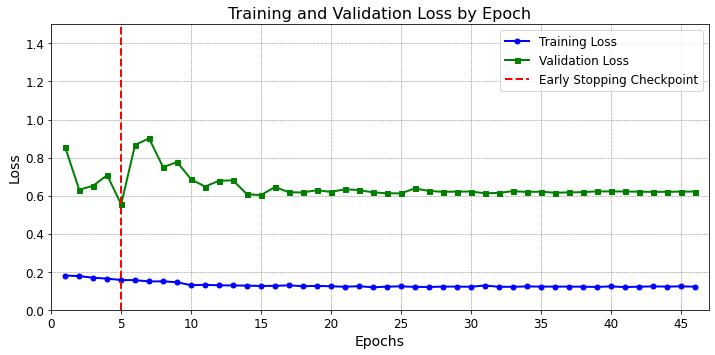

In [87]:
plot_losses(train_losses, valid_losses)

## Testing

### Load Best Model

In [65]:
model.load_state_dict(torch.load(best_model + file_name))

<All keys matched successfully>

### Test Loop

In [66]:
def test_model(model, dataloader):
    
    model.eval()

    with torch.no_grad():

        total = 0
        labels = []
        predictions = []

        for x, y, l in dataloader:

            x = x.to(device)
            y = y.to(device)
            l = l.cpu()
            y = y.long()

            outputs = model(x, l)
            prediction = nn.Softmax(dim=1)(outputs)
            prediction = prediction.detach().cpu().numpy()
            prediction = prediction[:,1]
            
            label = y.detach().cpu().numpy()

            labels.extend(label)
            predictions.extend(prediction)

        labels = np.array(labels)
        predictions = np.array(predictions)
    
    return labels, predictions

In [67]:
lstm_true_labels, lstm_prediction_probs = test_model(model, test_loader)

### LSTM Result

In [68]:
test_result['LSTM_PREDICT_PROB'] = lstm_prediction_probs 

### ROC

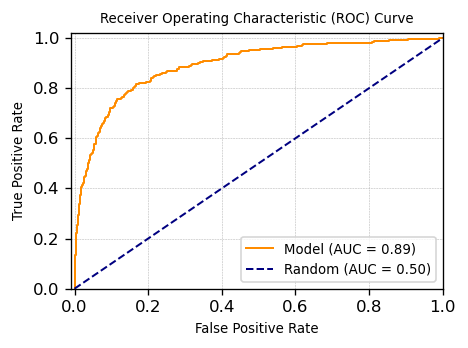

In [72]:
ROC_curve(lstm_true_labels, lstm_prediction_probs)

### Precision - Recall

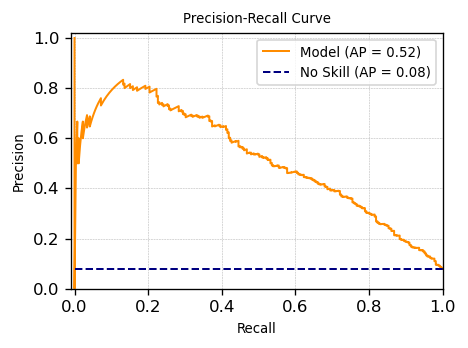

In [73]:
PRC_REC_curve(lstm_true_labels, lstm_prediction_probs)

### Set Decision Threshold

In [75]:
decision_recall = 0.8

In [76]:
predicted_label_lstm, decision_threshold_lstm = Prediction_Labels_Thresholding(lstm_true_labels, 
                                                                               lstm_prediction_probs, 
                                                                               decision_recall)

test_result['LSTM_PREDICT_LABEL'] = predicted_label_lstm

Decision Threshold is:  0.81


### Confusion Matrix

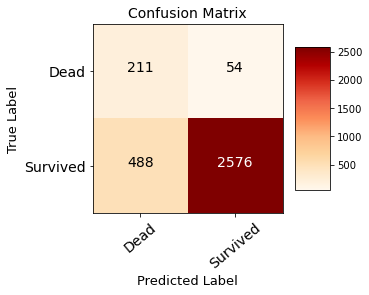

In [77]:
Confusion_Matrix(lstm_true_labels, predicted_label_lstm, classes = ['Dead', 'Survived'])

### Performance Metrics

In [78]:
Performance_Metrics(lstm_true_labels, predicted_label_lstm, lstm_prediction_probs)

ACC =  0.84
PRC =  0.3
REC =  0.8
F1M =  0.44
PPV =  0.3
NPV =  0.98
SEN =  0.8
SPE =  0.84
FPR =  0.16
FNR =  0.2
FDR =  0.7
AUC =  0.89
AP  =  0.52
MCC =  0.42


### Distribution of Prediction Probabilities

In [79]:
df_prediction_lstm_alive = test_result[test_result['ICU_FLAG'] == 'Survived']
df_prediction_lstm_dead  = test_result[test_result['ICU_FLAG'] == 'Dead']

### Alive Patients

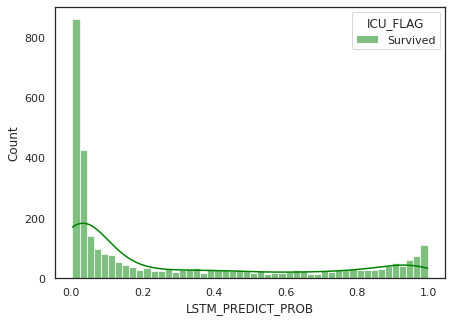

In [80]:
plt.figure(figsize=(7, 5))
sns.set(font_scale= 1)
sns.set_style(style='white')
sns.histplot(data=df_prediction_lstm_alive, x='LSTM_PREDICT_PROB', kde=True, stat='count', bins=50, fill=True,
             legend=True, hue='ICU_FLAG', palette=['green'])
plt.show()

### Dead Patients

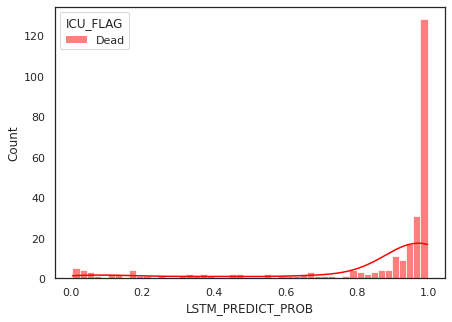

In [81]:
plt.figure(figsize=(7, 5))
sns.set(font_scale= 1)
sns.set_style(style='white')
sns.histplot(data=df_prediction_lstm_dead, x='LSTM_PREDICT_PROB', kde=True, stat='count', bins=50, fill=True,
             legend=True, hue='ICU_FLAG', palette=['red'])
plt.show()

### LSTM 

ROC AUC:  0.89
PR  AUC:  0.51
                   ________________________
                  |  Classification Report |
                   ‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾
              precision    recall  f1-score   support

    Negative       0.98      0.84      0.90      3064
    Positive       0.30      0.80      0.44       265

    accuracy                           0.84      3329
   macro avg       0.64      0.82      0.67      3329
weighted avg       0.93      0.84      0.87      3329

None


<site-packages>/plot_metric/functions.py:880: RuntimeWarning: invalid value encountered in divide
  fscore = (1 + beta ** 2) * (precision * recall) / ((beta ** 2 * precision) + recall)


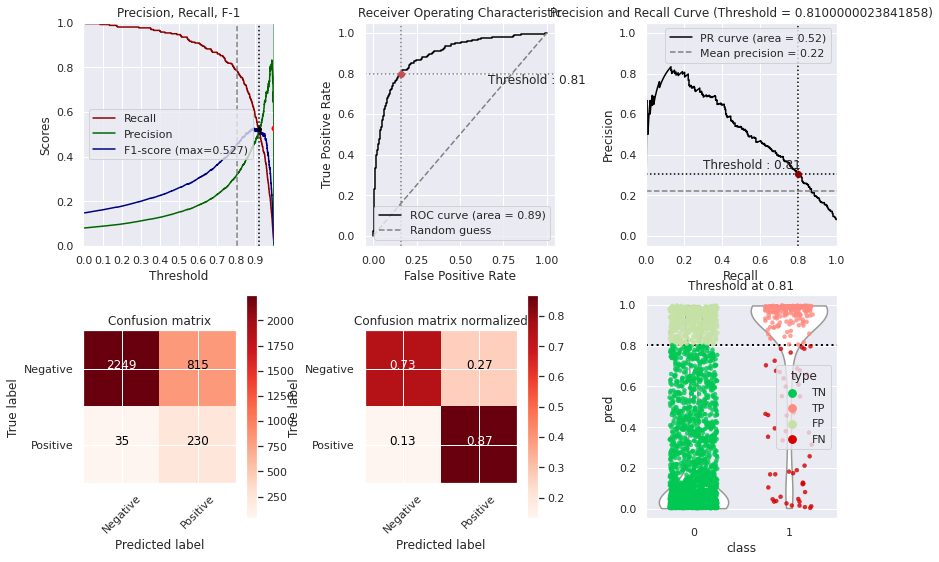

In [82]:
Binary_Classification_Performance(lstm_true_labels, lstm_prediction_probs, decision_threshold_lstm)

### Save Results

In [83]:
# test_result.to_csv("./Results/TimeVariant.csv", index=False)

### Bias & Fairness

In [83]:
test_result.head(3)

In [84]:
demog_col = ['patientid', 'gender', 'age']
df_demog = test_result[demog_col].copy()
df_demog = df_demog.drop_duplicates().reset_index(drop=True)

df_demog.loc[df_demog.gender == 1.0, 'gender'] = 'Male'
df_demog.loc[df_demog.gender == 2.0, 'gender'] = 'Female'

bins = [-np.inf, 35, 50, 60, 75, np.inf]
labels = ['Under 35', '36-50', '51-60', '61-75', 'Over 76']
df_demog['agegroup'] = pd.cut(df_demog['age'], bins=bins, labels=labels, right=False)
df_demog = df_demog.drop(columns= 'age')

In [85]:
df_demog.head(3)

### LSTM Result Frame

In [86]:
LSTM_df_bias = test_result[['patientid', 'LSTM_PREDICT_LABEL', 'icu_expire_flag']]
LSTM_df_bias = pd.merge(LSTM_df_bias, df_demog, on=['patientid'], how='left')

LSTM_df_bias.rename(columns={'gender': 'sex',
                             'patientid': 'entity_id',
                             'LSTM_PREDICT_LABEL': 'score', 
                             'icu_expire_flag': 'label_value'}, inplace=True)

LSTM_df_bias['sex']  = LSTM_df_bias.sex.astype(str)
LSTM_df_bias['score'] = LSTM_df_bias.score.astype(int)
LSTM_df_bias['agegroup'] = LSTM_df_bias.agegroup.astype(str)
LSTM_df_bias.head(3)

In [87]:
g = Group()

LSTMtab, _ = g.get_crosstabs(LSTM_df_bias, attr_cols=['sex', 'agegroup'])
LSTMtab['model_id'] = 'LSTM'
LSTMtab.head(3)

,model_id,score_threshold,k,attribute_name,attribute_value,accuracy,tpr,tnr,for,fdr,fpr,fnr,npv,precision,pp,pn,ppr,pprev,fp,fn,tn,tp,group_label_pos,group_label_neg,group_size,total_entities,prev
0,LSTM,binary 0/1,640,sex,Female,0.846543,0.648352,0.863014,0.032753,0.717703,0.136986,0.351648,0.967247,0.282297,209,977,0.326562,0.176223,150,32,945,59,91,1095,1186,3329,0.076728
1,LSTM,binary 0/1,640,sex,Male,0.824078,0.655172,0.839005,0.035047,0.735499,0.160995,0.344828,0.964953,0.264501,431,1712,0.673438,0.201120,317,60,1652,114,174,1969,2143,3329,0.081195
2,LSTM,binary 0/1,640,agegroup,36-50,0.814371,0.571429,0.830671,0.033457,0.815385,0.169329,0.428571,0.966543,0.184615,65,269,0.101562,0.194611,53,9,260,12,21,313,334,3329,0.062874


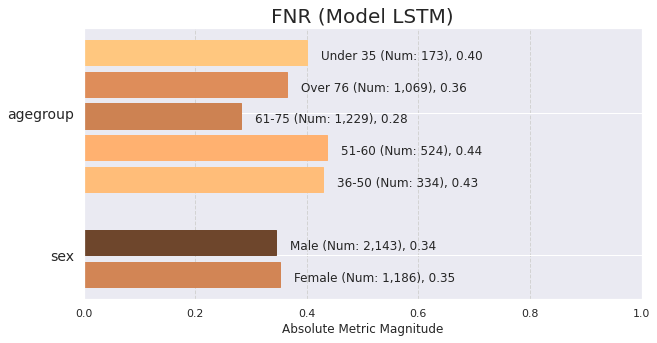

In [88]:
aqp = Plot()

a = aqp.plot_group_metric(LSTMtab, 'fnr', min_group_size=0.02)

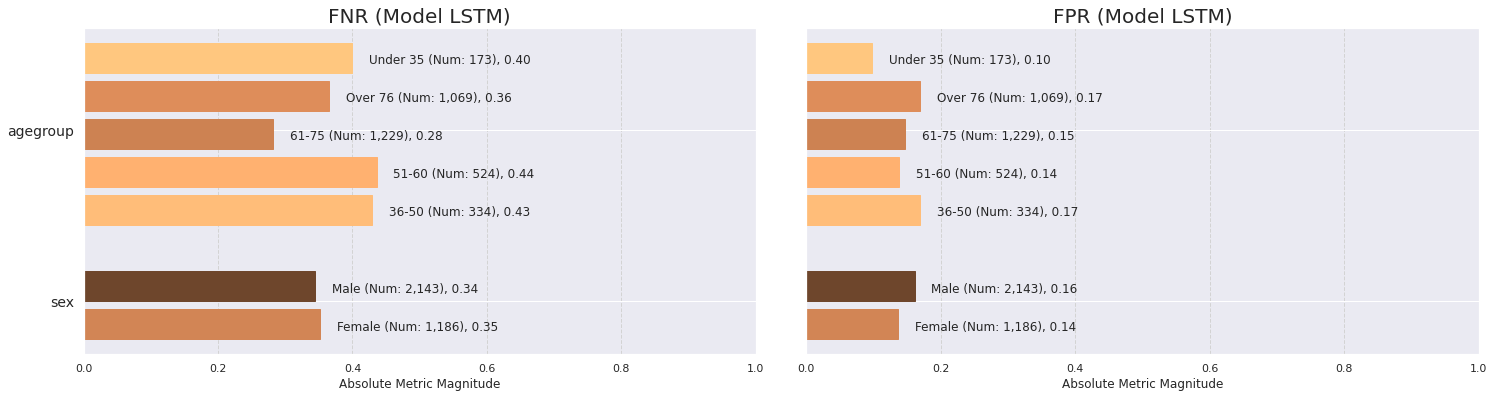

<Figure size 432x288 with 0 Axes>

In [89]:
a = aqp.plot_group_metric_all(LSTMtab, metrics=['fnr','fpr'], ncols=2, min_group_size=0.02)

In [90]:
b = Bias()

sex_ref = 'Male' 
age_ref = '51-60'

In [91]:
bdf = b.get_disparity_predefined_groups(LSTMtab, original_df=LSTM_df_bias, alpha=0.05, mask_significance=True,
                                        ref_groups_dict={'sex':sex_ref,'agegroup':age_ref})
majority_bdf = b.get_disparity_major_group(LSTMtab, original_df=LSTM_df_bias, mask_significance=True)
min_metric_bdf = b.get_disparity_min_metric(df=LSTMtab, original_df=LSTM_df_bias)
bdf.head(3)

,model_id,score_threshold,k,attribute_name,attribute_value,accuracy,tpr,tnr,for,fdr,fpr,fnr,npv,precision,pp,pn,ppr,pprev,fp,fn,tn,tp,group_label_pos,group_label_neg,group_size,total_entities,prev,ppr_disparity,pprev_disparity,precision_disparity,fdr_disparity,for_disparity,fpr_disparity,fnr_disparity,tpr_disparity,tnr_disparity,npv_disparity,ppr_ref_group_value,pprev_ref_group_value,precision_ref_group_value,fdr_ref_group_value,for_ref_group_value,fpr_ref_group_value,fnr_ref_group_value,tpr_ref_group_value,tnr_ref_group_value,npv_ref_group_value
0,LSTM,binary 0/1,640,sex,Female,0.846543,0.648352,0.863014,0.032753,0.717703,0.136986,0.351648,0.967247,0.282297,209,977,0.326562,0.176223,150,32,945,59,91,1095,1186,3329,0.076728,0.484919,0.876207,1.067279,0.975805,0.934562,0.850871,1.019780,0.989589,1.028616,1.002377,Male,Male,Male,Male,Male,Male,Male,Male,Male,Male
1,LSTM,binary 0/1,640,sex,Male,0.824078,0.655172,0.839005,0.035047,0.735499,0.160995,0.344828,0.964953,0.264501,431,1712,0.673438,0.201120,317,60,1652,114,174,1969,2143,3329,0.081195,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,Male,Male,Male,Male,Male,Male,Male,Male,Male,Male
2,LSTM,binary 0/1,640,agegroup,36-50,0.814371,0.571429,0.830671,0.033457,0.815385,0.169329,0.428571,0.966543,0.184615,65,269,0.101562,0.194611,53,9,260,12,21,313,334,3329,0.062874,0.730337,1.145798,0.746853,1.083123,0.856112,1.225740,0.983193,1.012987,0.963817,1.005852,51-60,51-60,51-60,51-60,51-60,51-60,51-60,51-60,51-60,51-60


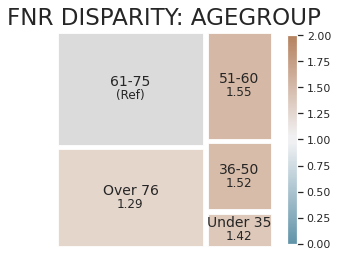

In [92]:
aqp.plot_disparity(majority_bdf, group_metric='fnr_disparity', attribute_name='agegroup', significance_alpha=0.05)

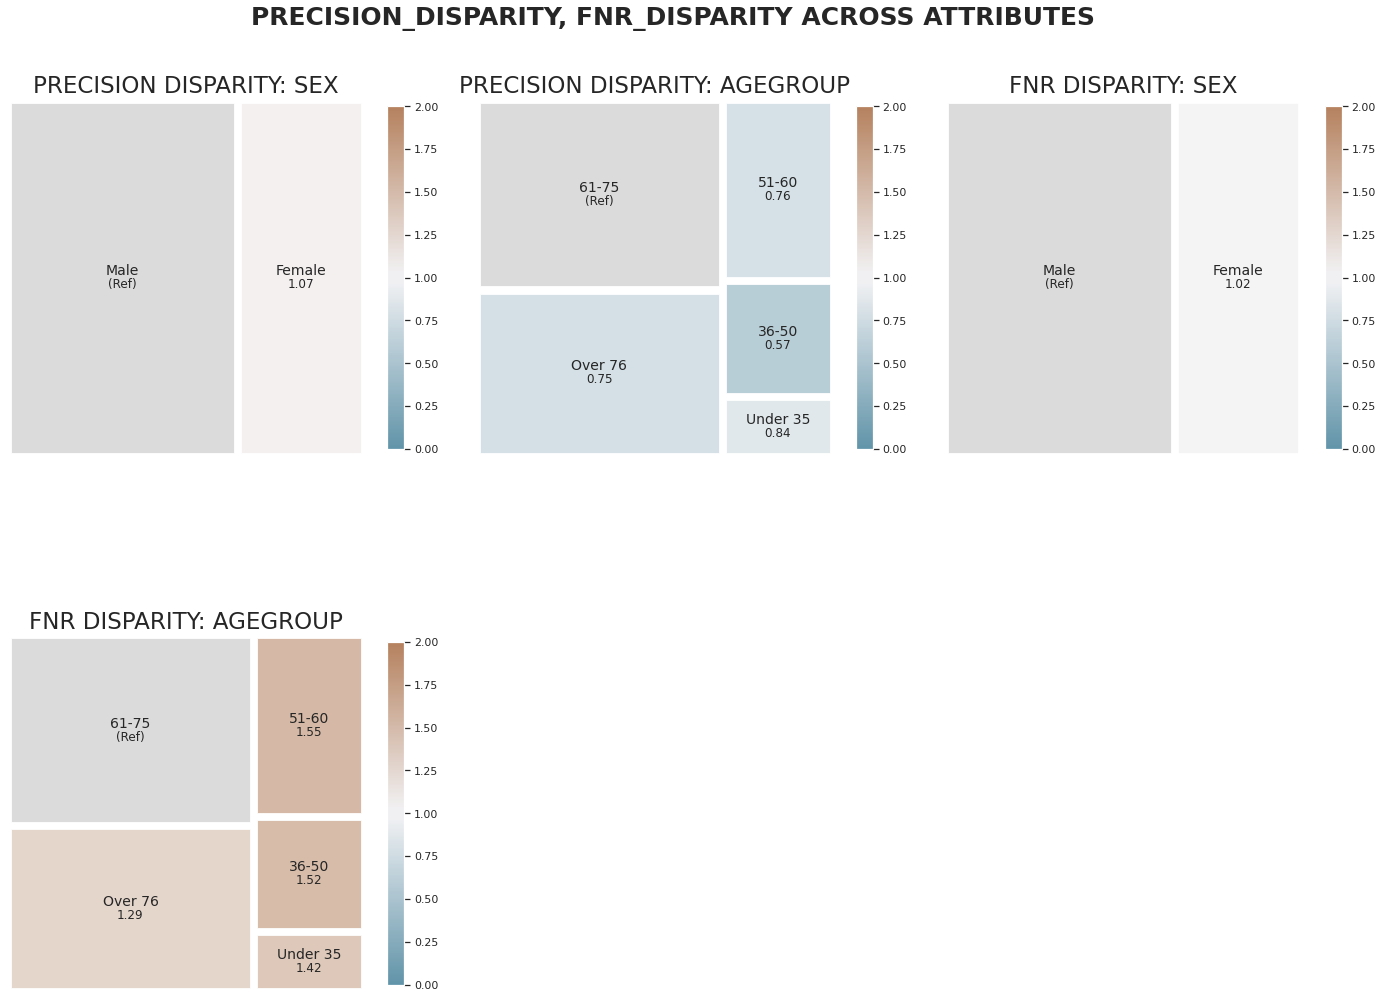

In [93]:
a = aqp.plot_disparity_all(majority_bdf, metrics=['precision_disparity', 'fnr_disparity'], significance_alpha=0.05)

In [94]:
f = Fairness()

fdf = f.get_group_value_fairness(bdf)
gaf = f.get_group_attribute_fairness(fdf)
fdf.head(3)

,model_id,score_threshold,k,attribute_name,attribute_value,accuracy,tpr,tnr,for,fdr,fpr,fnr,npv,precision,pp,pn,ppr,pprev,fp,fn,tn,tp,group_label_pos,group_label_neg,group_size,total_entities,prev,ppr_disparity,pprev_disparity,precision_disparity,fdr_disparity,for_disparity,fpr_disparity,fnr_disparity,tpr_disparity,tnr_disparity,npv_disparity,ppr_ref_group_value,pprev_ref_group_value,precision_ref_group_value,fdr_ref_group_value,for_ref_group_value,fpr_ref_group_value,fnr_ref_group_value,tpr_ref_group_value,tnr_ref_group_value,npv_ref_group_value,Statistical Parity,Impact Parity,FDR Parity,FPR Parity,FOR Parity,FNR Parity,TPR Parity,TNR Parity,NPV Parity,Precision Parity,TypeI Parity,TypeII Parity,Equalized Odds,Unsupervised Fairness,Supervised Fairness
0,LSTM,binary 0/1,640,sex,Female,0.846543,0.648352,0.863014,0.032753,0.717703,0.136986,0.351648,0.967247,0.282297,209,977,0.326562,0.176223,150,32,945,59,91,1095,1186,3329,0.076728,0.484919,0.876207,1.067279,0.975805,0.934562,0.850871,1.019780,0.989589,1.028616,1.002377,Male,Male,Male,Male,Male,Male,Male,Male,Male,Male,False,True,True,True,True,True,True,True,True,True,True,True,True,False,True
1,LSTM,binary 0/1,640,sex,Male,0.824078,0.655172,0.839005,0.035047,0.735499,0.160995,0.344828,0.964953,0.264501,431,1712,0.673438,0.201120,317,60,1652,114,174,1969,2143,3329,0.081195,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,Male,Male,Male,Male,Male,Male,Male,Male,Male,Male,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True
2,LSTM,binary 0/1,640,agegroup,36-50,0.814371,0.571429,0.830671,0.033457,0.815385,0.169329,0.428571,0.966543,0.184615,65,269,0.101562,0.194611,53,9,260,12,21,313,334,3329,0.062874,0.730337,1.145798,0.746853,1.083123,0.856112,1.225740,0.983193,1.012987,0.963817,1.005852,51-60,51-60,51-60,51-60,51-60,51-60,51-60,51-60,51-60,51-60,False,True,True,True,True,True,True,True,True,False,True,True,True,False,True


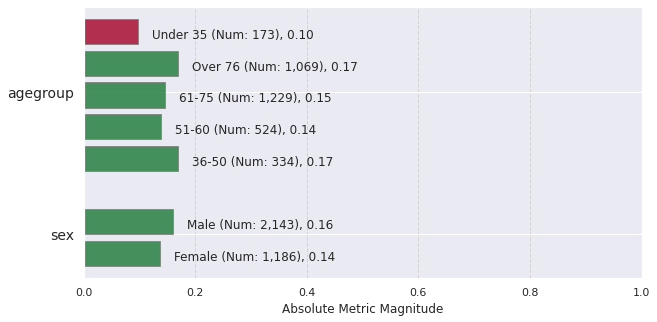

In [95]:
a = aqp.plot_fairness_group(fdf, group_metric='fpr', min_group_size=0.02)

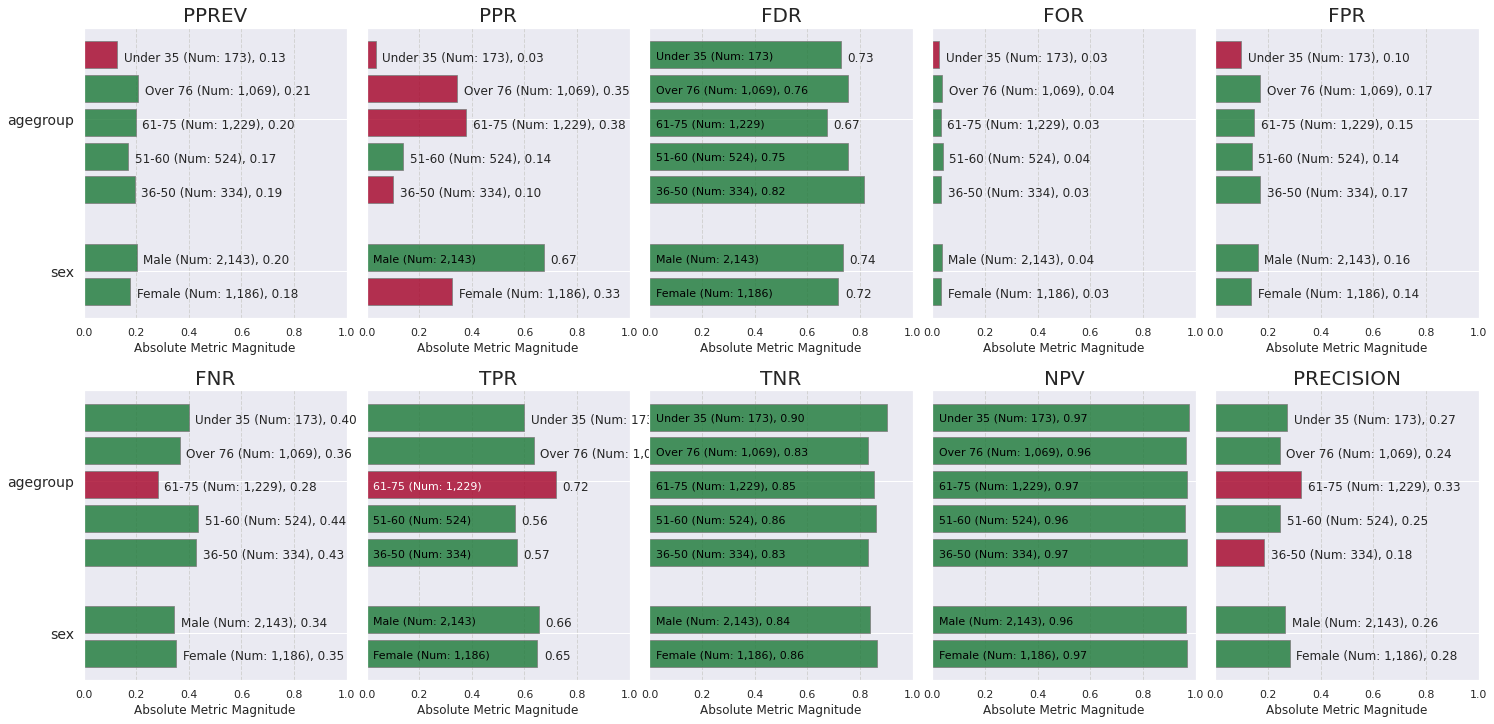

<Figure size 432x288 with 0 Axes>

In [96]:
a = aqp.plot_fairness_group_all(fdf, ncols=5, metrics = "all", min_group_size=0.02)

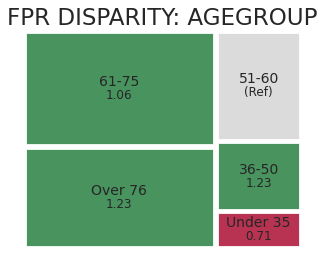

In [97]:
a = aqp.plot_fairness_disparity(fdf, group_metric='fpr', attribute_name='agegroup', min_group_size=0.02, significance_alpha=0.05)

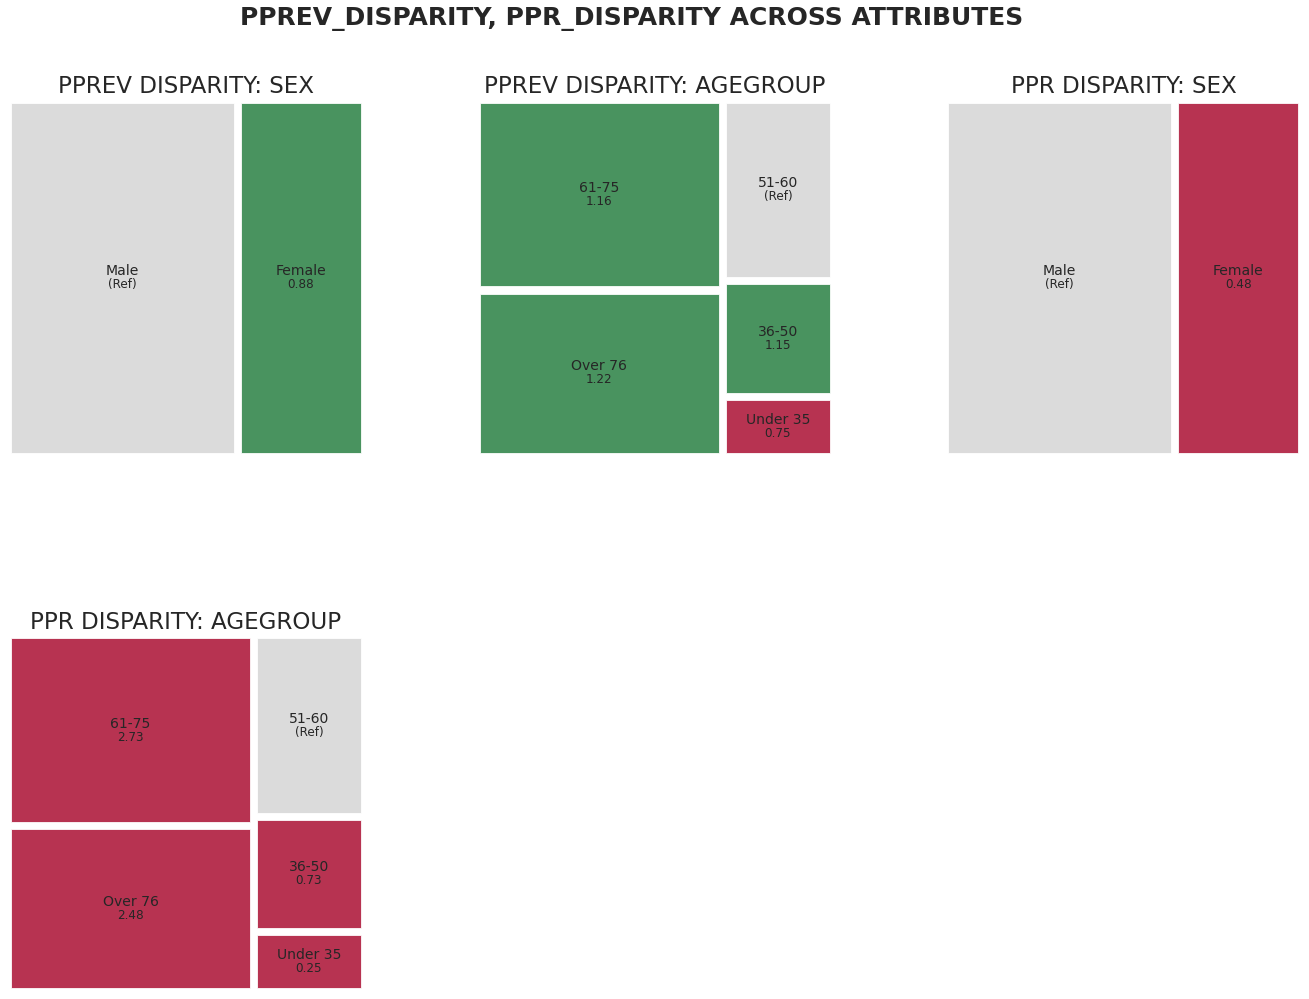

In [98]:
a = aqp.plot_fairness_disparity_all(fdf, metrics=['pprev_disparity', 'ppr_disparity'],  min_group_size=0.02, significance_alpha=0.05)

### Exploring Missing Percentage

In [99]:
df_missing = pd.read_csv(path_data + 'missing_all.csv', low_memory=False, index_col=False)
df_missing = df_missing[df_missing.raw_resolution == '60min']
df_missing.head(3)

In [100]:
used_cols = ['patientid']

used_cols.extend(continuse_col)
used_cols.extend(categorical_col)
used_cols.extend(binary_col)

In [101]:
df_missing = df_missing[used_cols]
df_missing.head(3)

In [102]:
test_missing = test_result[['patientid', 'icu_expire_flag', 'LSTM_PREDICT_PROB', 'LSTM_PREDICT_LABEL']].copy()

test_missing.head(3)

In [103]:
test_missing = test_missing.merge(df_missing, on='patientid', how='left')

test_missing['Label_Mistakes'] = 1
test_missing.loc[test_missing.icu_expire_flag == test_missing.LSTM_PREDICT_LABEL, 'Label_Mistakes'] = 0
test_missing.head(3)

### Statistical Tests

In [104]:
df = test_missing.copy()

In [105]:
correlation_results = {}

for column in df.columns[4:]:
    correlation, p_value = spearmanr(df['Label_Mistakes'], df[column])
    correlation_results[column] = {'Spearman Correlation': np.round(correlation, 3), 'p-value': np.round(p_value, 3)}

correlation_df = pd.DataFrame.from_dict(correlation_results, orient='index')

In [106]:
correlation_df.head(10)

,Spearman Correlation,p-value
Heart Rate,0.1,0.0
Temperature Central,-0.119,0.0
SpO2,-0.116,0.0
Invasive systolic arterial pressure,-0.128,0.0
Invasive diastolic arterial pressure,-0.127,0.0
Invasive mean arterial pressure,-0.127,0.0
Non-invasive systolic arterial pressure,0.187,0.0
Non-invasive diastolic arterial pressure,0.187,0.0
Non-invasive mean arterial pressure,0.187,0.0
ST1 (ECG ST elevation),-0.01,0.566


In [107]:
selected_vars = ['Heart Rate',
                 'Temperature Central',
                 'SpO2',
                 'Invasive systolic arterial pressure',
                 'Invasive diastolic arterial pressure',
                 'Invasive mean arterial pressure',
                 'ST1 (ECG ST elevation)',
                 'ST2 (ECG ST elevation)',
                 'ST3 (ECG ST elevation)',
                 'Respiratory Rate']

X_subset = df[selected_vars]
X_subset = sm.add_constant(X_subset)  
y = df['Label_Mistakes'] 

logit_model_subset = sm.Logit(y, X_subset).fit()
logit_model_subset.summary()

Optimization terminated successfully.
         Current function value: 0.408978
         Iterations 8


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:         Label_Mistakes   No. Observations:                 3329
Model:                          Logit   Df Residuals:                     3318
Method:                           MLE   Df Model:                           10
Date:                Wed, 03 Apr 2024   Pseudo R-squ.:                 0.09632
Time:                        22:22:05   Log-Likelihood:                -1361.5
converged:                       True   LL-Null:                       -1506.6
Covariance Type:            nonrobust   LLR p-value:                 1.798e-56
========================================================================================================
                                           coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------
const                                   -0.4983      0.190     -2.626      0.009      -0.870      -0.126
Heart Rate                               0.1988      0.029      6.846      0.000       0.142       0.256
Temperature Central                     -0.0028      0.002     -1.388      0.165      -0.007       0.001
SpO2                                    -0.1567      0.027     -5.782      0.000      -0.210      -0.104
Invasive systolic arterial pressure     -0.3244      0.223     -1.455      0.146      -0.761       0.113
Invasive diastolic arterial pressure     0.2827      0.323      0.875      0.382      -0.351       0.916
Invasive mean arterial pressure          0.0457      0.284      0.161      0.872      -0.510       0.602
ST1 (ECG ST elevation)                  -0.0080      0.002     -5.220      0.000      -0.011      -0.005
ST2 (ECG ST elevation)                   0.0019      0.003      0.576      0.564      -0.005       0.009
ST3 (ECG ST elevation)                   0.0049      0.004      1.324      0.186      -0.002       0.012
Respiratory Rate                        -0.0309      0.003    -10.385      0.000      -0.037      -0.025
========================================================================================================
"""

## Interpretation

### Integrated Gradients

In [108]:
def custom_eval(model):
    for module in model.modules():
        if isinstance(module, nn.Dropout):
            module.eval()
        elif isinstance(module, nn.BatchNorm2d): 
            module.eval()

In [109]:
custom_eval(model) 
model.zero_grad()

In [110]:
batch_size = 1

test_loader  = DataLoader(test_dataset , batch_size=batch_size, shuffle=False, **kwargs)
test_dataloader_iter = iter(test_loader)

In [111]:
batch = next(test_dataloader_iter)

In [112]:
X, y, l = batch 
baseline = torch.zeros_like(X)

In [113]:
integrated_gradients = IntegratedGradients(model)

In [114]:
X.requires_grad_() 
baseline.requires_grad_() 

X = X.cuda()
baseline = baseline.cuda()
model.cuda()

RNN(
  (lstm): LSTM(264, 128, batch_first=True, bidirectional=True)
  (classification_head): Sequential(
    (0): Linear(in_features=256, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.0, inplace=False)
    (3): Linear(in_features=32, out_features=2, bias=True)
  )
)

In [115]:
torch.backends.cudnn.enabled = False
attributions = integrated_gradients.attribute(X, baselines=baseline, target=int(y.item()), additional_forward_args=(l,))
torch.backends.cudnn.enabled = True

In [116]:
heatmap_data = attributions[0].cpu().detach().numpy()
attributions_sum = attributions[0].sum(dim=0).cpu().detach().numpy()

In [117]:
ind_features = [name for name in columns if name.endswith('_ind')]
non_ind_features = [name for name in columns if not name.endswith('_ind')]

ind_heatmap = heatmap_data[:, [columns.index(name) for name in ind_features]]
non_ind_heatmap = heatmap_data[:, [columns.index(name) for name in non_ind_features]]

ind_attributions = attributions_sum[[columns.index(name) for name in ind_features]]
non_ind_attributions = attributions_sum[[columns.index(name) for name in non_ind_features]]

In [118]:
def plot_heatmap(data, feature_names):
    
    plt.figure(figsize=(18, 10))
    
    cmap = sns.diverging_palette(250, 10, as_cmap=True)

    ax = sns.heatmap(np.array(list(reversed(data))), 
                     annot=False, fmt=".2f", cmap='coolwarm', 
                     xticklabels=feature_names, yticklabels=['Hour ' + str(i+1) for i in reversed(range(data.shape[0]))],
                     linewidths=0.5, linecolor='gray', center=0)

    ax.set_title('Attribution Heatmap', fontsize=20, pad=20)
    ax.set_xlabel('Features', fontsize=16, labelpad=10)
    ax.set_ylabel('Sequence Step', fontsize=16, labelpad=10)
    plt.xticks(rotation=45, ha='right')  
    plt.yticks(rotation=0)  
    cbar = ax.collections[0].colorbar
    cbar.set_label('Attribution', fontsize=16, labelpad=10)
    cbar.ax.tick_params(labelsize=12)
    plt.tight_layout()
    plt.show()

In [119]:
def plot_feature_attributions(data, feature_names):
    
    plt.figure(figsize=(18, 12))

    bars = plt.bar(range(len(data)), data, color='skyblue', edgecolor='blue')

    for bar in bars:
        yval = bar.get_height()
        if yval >= 0: 
            plt.text(bar.get_x() + bar.get_width()/2, yval + 0.005, round(yval, 2), 
                     ha='center', va='bottom', fontsize=10)
        else:
            plt.text(bar.get_x() + bar.get_width()/2, yval - 0.005, round(yval, 2), 
                     ha='center', va='bottom', fontsize=10)

    plt.xticks(range(len(data)), feature_names, rotation=45, ha="right", fontsize=12)
    
    plt.ylabel('Attribution', fontsize=14)
    plt.xlabel('Features', fontsize=14)
    plt.title('Feature Attributions', fontsize=16)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

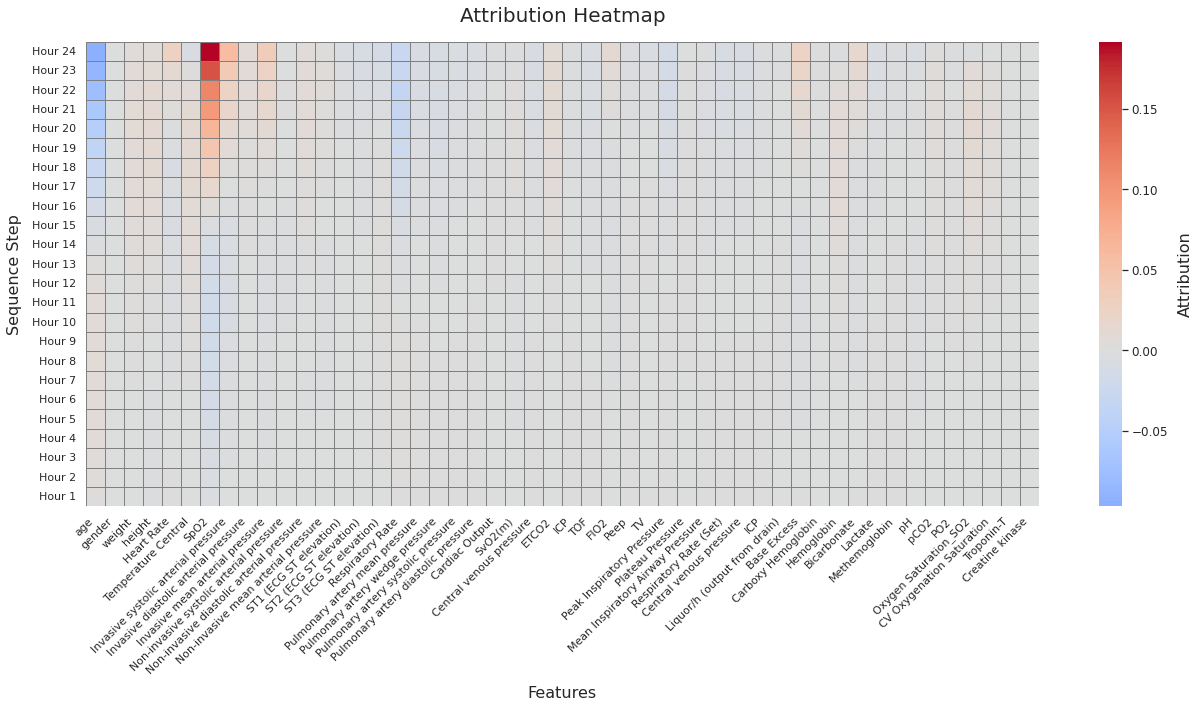

In [120]:
plot_heatmap(non_ind_heatmap[:,:50], non_ind_features[:50])

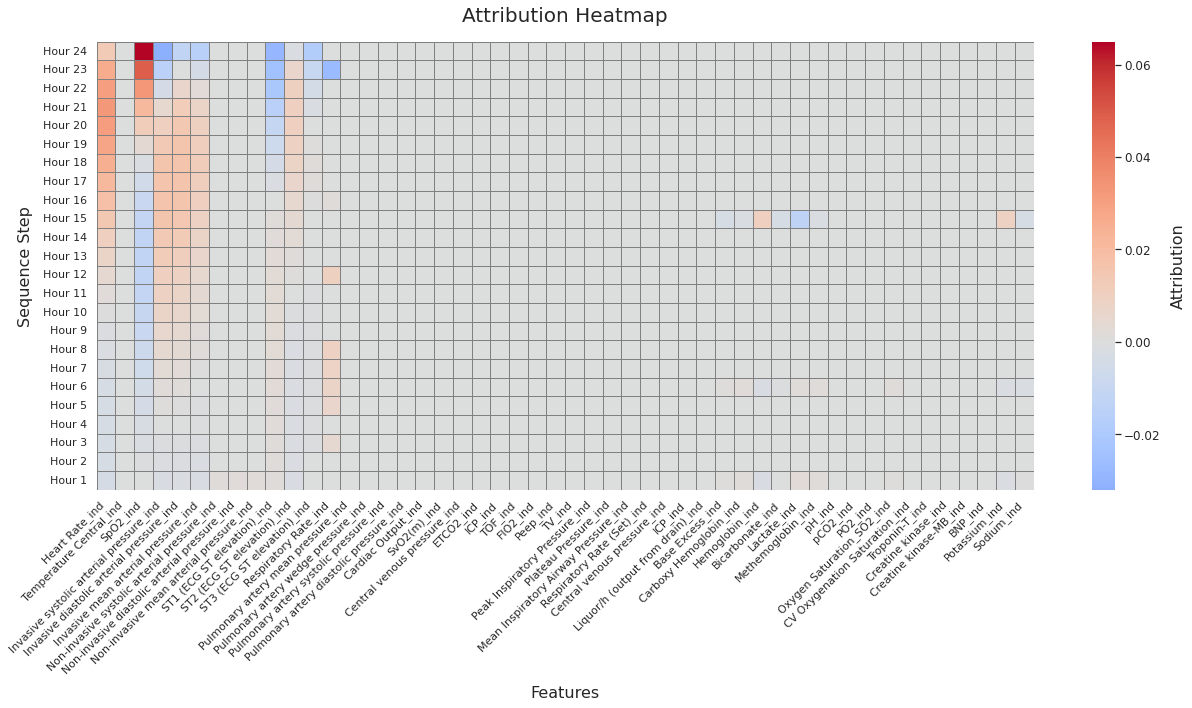

In [121]:
plot_heatmap(ind_heatmap[:,:50], ind_features[:50])

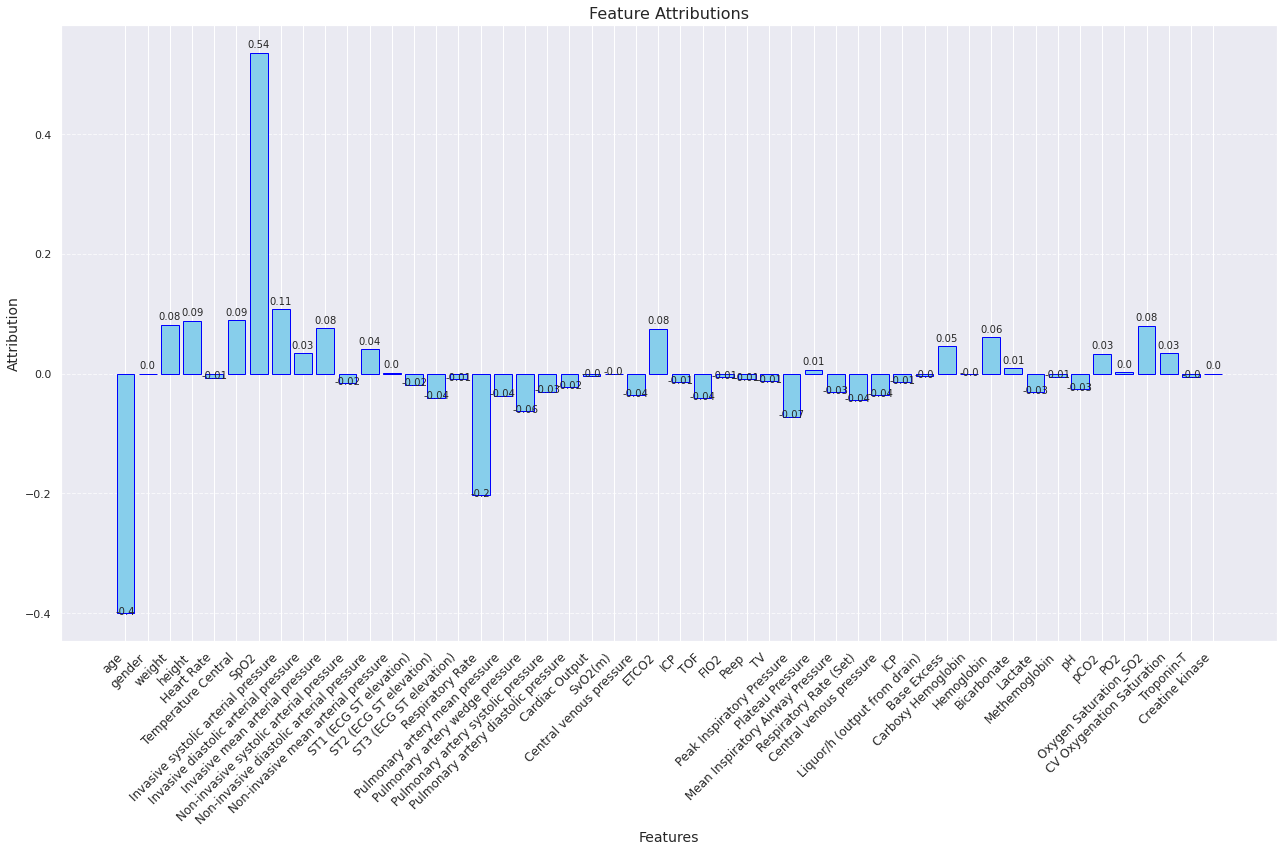

In [122]:
plot_feature_attributions(non_ind_attributions[:50], non_ind_features[:50])

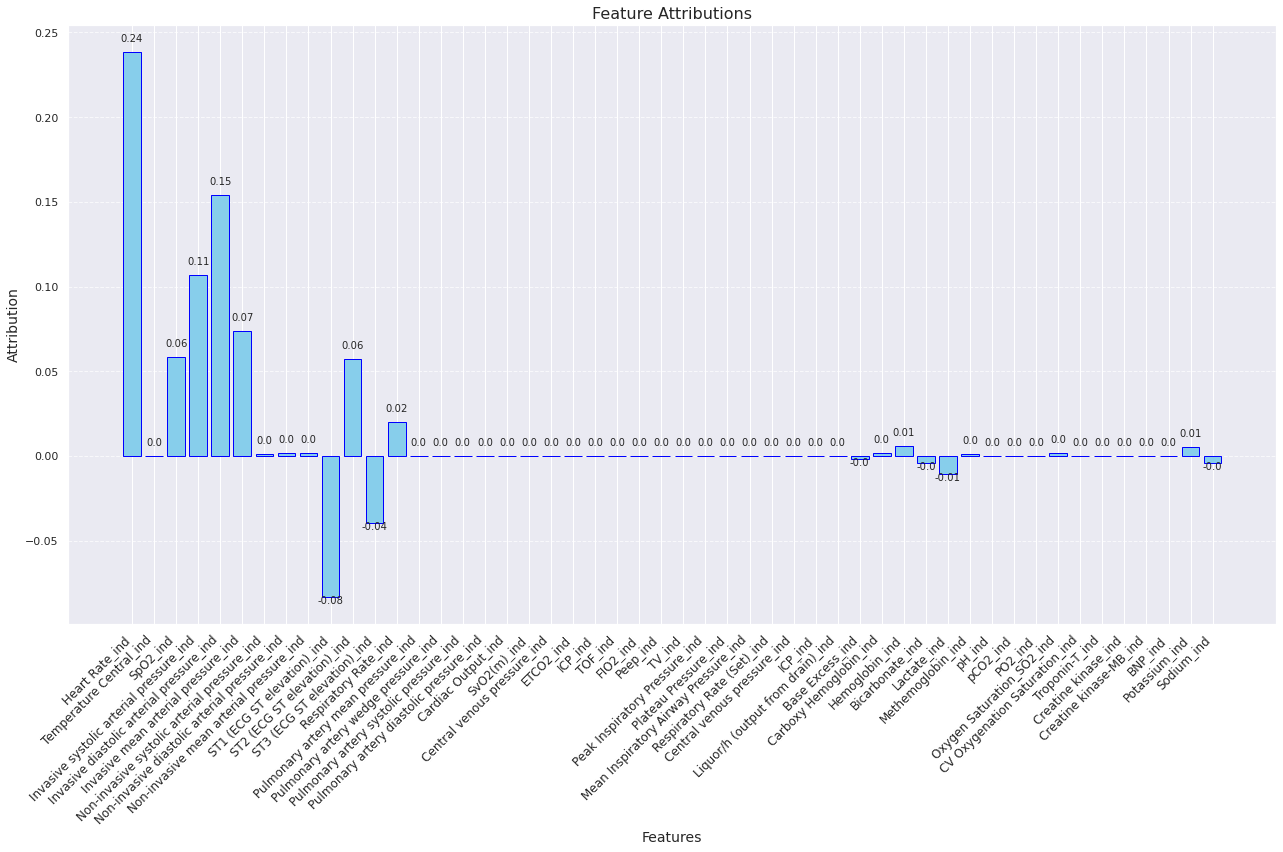

In [123]:
plot_feature_attributions(ind_attributions[:50], ind_features[:50])

### Feature Ablation 

In [124]:
batch_size = 1

test_loader  = DataLoader(test_dataset , batch_size=batch_size, shuffle=False, **kwargs)
test_dataloader_iter = iter(test_loader)

In [125]:
batch = next(test_dataloader_iter)

In [126]:
def ablate_and_predict(model, data, ablation_type='time_step', ablation_index=[]):
    
    model.eval()
    
    x, y, l = data
    
    x = x.to(device)
    y = y.to(device)
    l = l.cpu()
    y = y.long()

    seq_lengths, perm_idx = l.sort(0, descending=True) 
    x = x[perm_idx]
    y = y[perm_idx]

    with torch.no_grad():
        baseline_out = model(x, seq_lengths)
        baseline_out = nn.Softmax(dim=1)(baseline_out)
        baseline_out = baseline_out[:,1].detach().cpu().numpy()
    
    ablation_results = {}
    
    for index in ablation_index:
        
        X_ablated = x.clone()
        
        if ablation_type == 'time_step':
            X_ablated[:, index, :] = 0  
        elif ablation_type == 'feature':
            X_ablated[:, :, index] = 0  
        
    with torch.no_grad():
        ablated_out = model(X_ablated, seq_lengths)
        ablated_out = nn.Softmax(dim=1)(ablated_out)
        ablated_out = ablated_out[:,1].detach().cpu().numpy()

    ablation_results = abs(baseline_out - ablated_out)[0]  
        
    return ablation_results

In [127]:
def ablate_all_time_steps(model, data):

    num_time_steps = data[0].shape[1]  
    
    ablation_results = {}
    
    for time_step in range(num_time_steps):
        
        ablation_difference = ablate_and_predict(model, data, ablation_type='time_step', ablation_index=[time_step])
        ablation_results['Hour ' + str(time_step + 1)] = np.round(ablation_difference, 4)
    
    return ablation_results

In [128]:
def ablate_features(model, data, feature_names):
    
    feature_groups = {}
    for feature in feature_names:
        if '_ind' in feature:
            base_feature = feature.replace('_ind', '')
            if base_feature in feature_groups:
                feature_groups[base_feature].append(feature)
            else:
                feature_groups[base_feature] = [feature]
        else:
            feature_groups[feature] = [feature]
    
    feature_indices = {name: [feature_names.index(f) for f in group] for name, group in feature_groups.items()}
    
    ablation_results = {}
    
    for feature, indices in feature_indices.items():
        ablation_difference = ablate_and_predict(model, data, ablation_type='feature', ablation_index=indices)
        ablation_results[feature] = np.round(ablation_difference, 4)
        
    sorted_ablation_results = {k: v for k, v in sorted(ablation_results.items(), key=lambda item: item[1], reverse=True)}

    
    return sorted_ablation_results

In [129]:
def plot_feature_importance(results):
    
    time_steps = list(results.keys())
    importance_values = [results[time_step] for time_step in time_steps]
    
    sns.set(style="whitegrid")
    plt.figure(figsize=(10, 6))
    
    sns.barplot(x=time_steps, y=importance_values, palette='viridis')
    
    plt.title('Feature Importance Over Time Steps', fontsize=16)
    plt.xlabel('Time Step',  fontsize=14)
    plt.ylabel('Importance', fontsize=14)
    plt.xticks(rotation=35)
    plt.tight_layout()
    plt.show()

In [130]:
time_importance = ablate_all_time_steps(model, batch)

In [131]:
feature_importance = ablate_features(model, batch, columns)

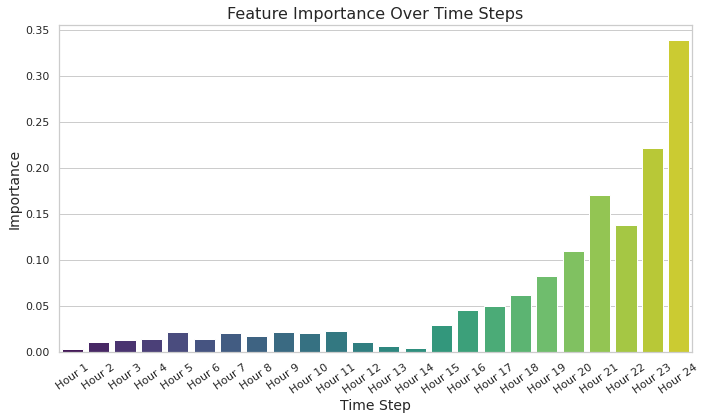

In [132]:
plot_feature_importance(time_importance)

In [133]:
number_top_features = 30

top_importance = list(feature_importance.values())[:30]
top_features = list(feature_importance.keys())[:30]

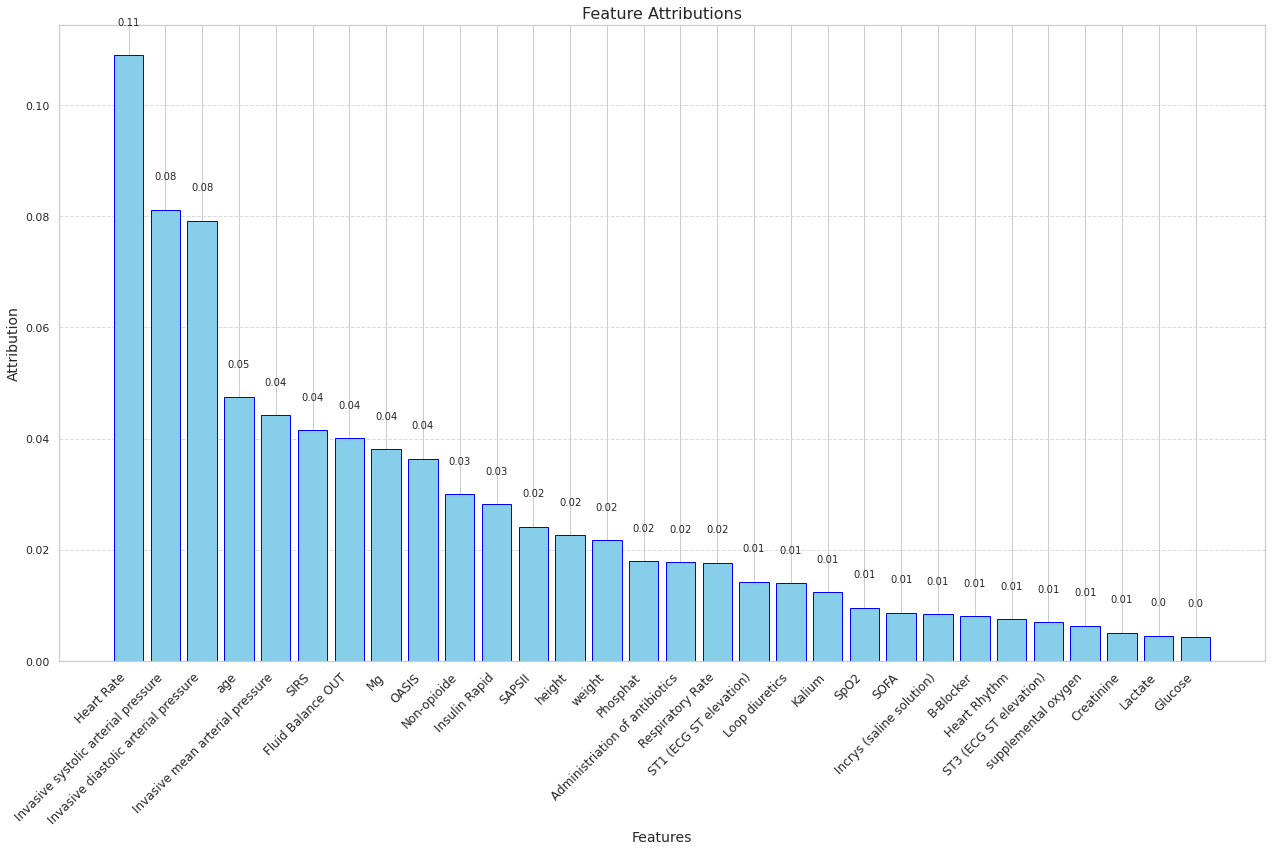

In [134]:
plot_feature_attributions(top_importance, top_features)